<div style="text-align:center; padding:1px 0;">

<p style="font-size:20px; color:#B0B0B0; margin-bottom:6px;">
PROJECT TITLE
</p>

<h1 style="font-size:35px; font-weight:``500; margin-top:0;">
Multiclass Sleep Health Risk Classification & Explainable AI System
</h1>

</div>

<div style = "font-size:16px; line-height:1.6;">

### Phase 1] Project Definition

This project develops and evaluates a machine learning solution for **multiclass sleep disorder classification**, with model interpretation using SHAP and deployment through Flask.

---

### 1.1] Domain

**Healthcare Analytics** • **Machine Learning** • **Explainable AI (XAI)**

---

### 1.2] Problem Statement

Sleep health can be influenced by demographic, lifestyle, and physiological factors. This project uses these attributes to classify individuals into three sleep-disorder categories:

- **No Sleep Disorder**
- **Insomnia**
- **Sleep Apnea**

The goal is to build a reliable multiclass classification model while understanding which features contribute to its predictions.

---

### 1.3] Business Objective

Sleep disorders such as Insomnia and Sleep Apnea often go undiagnosed until symptoms become severe, since routine health checkups rarely screen for them directly. The business objective of this project is to enable **early, low-cost identification of at-risk individuals** using data that is already commonly collected — demographic, lifestyle, and physiological attributes — without requiring a dedicated clinical sleep study.

The resulting system is designed to function as a **screening and triage aid, not a diagnostic tool** — helping platforms such as health apps, wellness programs, or insurers flag individuals who may benefit from professional follow-up, so clinical attention is directed where it is most needed.

To support real-world adoption, the solution is built to be:

- **Accessible** — classifies sleep-disorder risk from readily available health and lifestyle attributes, not specialized clinical tests.
- **Reliable under class imbalance** — evaluated using class-aware metrics (Macro F1) so minority disorder classes are not overlooked in favor of the majority "healthy" class.
- **Interpretable** — every prediction is explainable via **SHAP**, building the clinical and end-user trust required for adoption.
- **Deployable** — packaged as a working **Flask web application**, so the pipeline can realistically sit behind a product rather than remain a research notebook.

---

### 1.4] Machine Learning Objective

Build, compare, tune, and evaluate supervised multiclass classification models using stratified cross-validation, appropriate class-imbalance techniques, and class-level performance metrics.

The final model is selected based on **generalization performance, balanced class performance, and robustness on unseen test data**.

---

### 1.5] Problem Formulation

| **Attribute** | **Description** |
|:--------------|:----------------|
| **Learning Type** | Supervised Learning |
| **Problem Category** | Multiclass Classification |
| **Target Variable** | Sleep Disorder |
| **Target Classes** | No Sleep Disorder, Insomnia, Sleep Apnea |

---

### Project Initialization

This section initializes the project environment by importing the required libraries, loading the dataset, and configuring the notebook for a consistent machine learning workflow.

### A] Import Libraries

Import the libraries required for data preparation, visualization, model development, evaluation, explainability, and model serialization.


In [77]:
# ============================================================
# Standard Library
# ============================================================

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Data Manipulation
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# Data Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Plot Settings
# ============================================================

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

# ============================================================
# Machine Learning - Data Preprocessing
# ============================================================

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.impute import SimpleImputer

# ============================================================
# Machine Learning Models
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

# ============================================================
# Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ============================================================
# Explainable AI (SHAP)
# ============================================================

import shap

# ============================================================
# Model Serialization
# ============================================================

import joblib

# ============================================================
# Utility
# ============================================================

from IPython.display import display

### B] Load Dataset

<div style = "font-size:16px; line-height:1.6;">

**Note:** The parameter `keep_default_na=False` ensures that text values such as `"None"` are preserved as valid category labels instead of being automatically interpreted as missing (`NaN`) values during data import.

</div>

### C] Notebook Configuration

<div style = "font-size:16px; line-height:1.6;">

Configure the notebook environment by applying display settings, visualization preferences to ensure a clean and consistent workflow throughout the project

**Configuration includes:**

- Display settings for improved data readability.
- Visualization settings for consistent plot formatting.
- Warning suppression to maintain a clean notebook output

</div>


In [78]:
df = pd.read_excel(r"C:\Users\Rushikesh\OneDrive\Desktop\Sleep_Health_Lifestyle_Dataset.xlsx",keep_default_na=False)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# Visualization settings
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")


### Phase 2] : Initial Data Preparation

<div style = "font-size:16px; line-height:1.6;">

### Objective

This phase focuses on improving the consistency, quality, and structural integrity of the raw dataset before analysis. It standardizes data representations, resolves formatting inconsistencies, and validates feature structures without performing any machine learning-specific preprocessing or altering the underlying data distribution.



### 2.1] Non-Predictive Feature Removal — Person ID

- Removed the **`Person ID`** column as it is a unique record identifier with no meaningful predictive value.
- Excluding identifier fields prevents the model from learning irrelevant record-specific patterns.

</div>


In [79]:
# Remove Non-Predictive Identifier
df = df.drop(columns=["Person ID"])

print("=" * 70)
print("NON-PREDICTIVE FEATURE REMOVAL")
print("=" * 70)


NON-PREDICTIVE FEATURE REMOVAL


### 2.2] Duplicate Record Inspection

<div style="font-size:16px; line-height:1.6;">

Duplicate records can introduce bias into statistical summaries, visualizations, and machine learning models by representing the same observation multiple times. Therefore, the dataset is inspected for duplicate rows before any further analysis.

If duplicate records are identified, they are removed to ensure that each observation represents a unique individual and to maintain data integrity throughout the project.

</div>

### 2.2.1] Removing Duplicate Records

<div style="font-size:16px; line-height:1.6;">

After inspecting the dataset, duplicate records are removed to eliminate redundant observations. This ensures that subsequent analyses and model training are performed on unique data entries only.

</div>


In [80]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("="*60)
print(f"Duplicate Records Found : {duplicate_count}")
print("="*60)

# Remove duplicate records
df.drop_duplicates(inplace=True)

print("=" * 70)
print("Duplicate records removed successfully.")
print(f"Updated Dataset Shape : {df.shape}")
print("=" * 70)


Duplicate Records Found : 50
Duplicate records removed successfully.
Updated Dataset Shape : (10000, 12)


### 2.3] Categorical Value Inspection

<div style="font-size:16px; line-height:1.6;">

Before standardizing categorical variables, the unique values of each category are examined to identify inconsistencies introduced during data collection or manual entry. This inspection helps detect issues such as inconsistent capitalization, spelling variations, unintended whitespace, and duplicate category names.

The identified inconsistencies provide the basis for the standardization process performed in the subsequent step.

</div>

### 2.4] Text Standardization

<div style="font-size:16px; line-height:1.6;">

Text-based columns may contain unintended leading or trailing whitespace introduced during data collection or manual entry. These inconsistencies can result in identical categories being treated as separate values.

Whitespace is removed from all text columns to ensure consistent categorical representations throughout the dataset.

</div>

### 2.5] Categorical Value Standardization

<div style="font-size:16px; line-height:1.6;">

Categorical variables may contain inconsistent naming conventions due to differences in capitalization or manual data entry (for example, `FEMALE`, `female`, and `Female`).

These inconsistencies are standardized to establish a uniform representation for each category, thereby improving data quality and ensuring reliable analysis throughout the project.

</div>


In [81]:
columns = ["Gender","Occupation", "BMI Category"]

for col in columns:
    print("="*70)
    print(f" Column: {col}")
    print("="*70)
    print(sorted(df[col].dropna().unique()))

# Removing Leading & Trailing Whitespaces
# Apply only to categorical/text features

text_columns = [
    "Gender",
    "Occupation",
    "BMI Category",
    "Blood Pressure",
    "Sleep Disorder"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

print("=" * 70)
print("Leading & Trailing Whitespaces Removed Successfully")
print("=" * 70)

# Standardize Gender
df["Gender"] = df["Gender"].str.title()

# Standardize Occupation
df["Occupation"] = df["Occupation"].str.title()

# Standardize BMI Category
df["BMI Category"] = df["BMI Category"].str.title()

# Replace Inconsistent BMI Category
df["BMI Category"] = df["BMI Category"].replace({
    "Over Weight": "Overweight"
})


 Column: Gender
['', ' Female', ' Male', 'FEMALE', 'Female', 'Female ', 'MALE', 'Male', 'Male ', 'female', 'male']
 Column: Occupation
['', ' Accountant', ' Doctor', ' Engineer (Non-Software)', ' Entrepreneur', ' Lawyer', ' Manager', ' Nurse', ' Sales Representative', ' Scientist', ' Software Engineer', ' Student', ' Teacher', 'ACCOUNTANT', 'Accountant', 'Accountant ', 'Doctor', 'Doctor ', 'ENTREPRENEUR', 'Engineer (Non-Software)', 'Engineer (Non-Software) ', 'Entrepreneur', 'Entrepreneur ', 'Lawyer', 'Lawyer ', 'Manager', 'Manager ', 'Nurse', 'Nurse ', 'SOFTWARE ENGINEER', 'Sales Representative', 'Sales Representative ', 'Scientist', 'Scientist ', 'Software Engineer', 'Software Engineer ', 'Student', 'Student ', 'Teacher', 'Teacher ', 'lawyer']
 Column: BMI Category
['', 'NORMAL', 'Normal', 'Normal ', 'OBESE', 'OVERWEIGHT', 'Obese', 'Obese ', 'Over Weight', 'Overweight', 'Overweight ', 'UNDERWEIGHT', 'Underweight', 'Underweight ', 'normal', 'obese', 'overweight', 'underweight']
Leadin

### 2.6] Missing Value Standardization

<div style = "font-size:15px; line-height:1.6;"

Standardize missing data representation by converting empty string (`""`) values to `NaN`, ensuring consistent handling of missing values throughout the machine learning pipeline.

</div>

### 2.7] Data Type Correction

<div style="font-size:16px; line-height:1.6;">

Several numerical variables were initially loaded as text because of inconsistent formatting and non-standard missing value representations.

Each feature is converted to its appropriate data type to enable accurate statistical analysis, visualization, and machine learning operations.

</div>


In [82]:
# Convert blank strings to missing values (NaN)
df.replace("", np.nan, inplace=True)

# Numerical columns
numeric_columns = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

# Convert to numeric
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("=" * 70)
print(df.dtypes)
print("=" * 70)


Gender                      object
Age                        float64
Occupation                  object
Sleep Duration             float64
Quality of Sleep           float64
Physical Activity Level    float64
Stress Level               float64
BMI Category                object
Blood Pressure              object
Heart Rate                 float64
Daily Steps                float64
Sleep Disorder              object
dtype: object


### 2.8] Blood Pressure Feature Standardization

<div style="font-size:16px; line-height:1.6;">

The Blood Pressure feature is initially stored as a combined value containing both systolic and diastolic measurements (for example, `120/80`).

To improve analytical flexibility and support independent analysis of each measurement, the feature is decomposed into two separate numerical variables: **Systolic Blood Pressure** and **Diastolic Blood Pressure**.

</div>

### 2.9] Target Class Standardization

<div style = "font-size:15px; line-height:1.6;"

Standardize the target variable by replacing the class label **"None"** with **"No Sleep Disorder"** to improve clarity, interpretability, and consistency throughout the machine learning pipeline.

</div>


In [83]:
# Split Blood Pressure into 2 Columns
df[["Systolic BP","Diastolic BP"]] = (df["Blood Pressure"].str.split("/", expand = True))

# Convert to Numeric
df["Systolic BP"] = pd.to_numeric(df["Systolic BP"], errors = "coerce")
df["Diastolic BP"] = pd.to_numeric(df["Diastolic BP"], errors = "coerce")

# Drop Original Column
df.drop(columns = "Blood Pressure", inplace = True)
print("="*70)
print("Blood Pressure Feature Standardized ")

# Rename target class from 'None' to 'No Sleep Disorder'
df["Sleep Disorder"] = df["Sleep Disorder"].replace(
    "None", "No Sleep Disorder"
)


Blood Pressure Feature Standardized 


### 2.10] Data Validation

<div style="font-size:16px; line-height:1.6;">

Following the initial data preparation process, the dataset is validated to confirm that all cleaning and standardization operations have been successfully applied.

This validation includes reviewing the missing values, duplicate records, and categorical consistency before proceeding to the exploratory data analysis stage.

</div>

In [84]:
# Missing Values
print(df.isnull().sum())

# Duplicate Records
print(df.duplicated().sum())

# Unique Categories
for col in df.select_dtypes(include="object"):
    print(f"\n{col}")
    print(df[col].unique())

Gender                     228
Age                        222
Occupation                 256
Sleep Duration             276
Quality of Sleep           292
Physical Activity Level    540
Stress Level               261
BMI Category               407
Heart Rate                 386
Daily Steps                269
Sleep Disorder               0
Systolic BP                262
Diastolic BP               262
dtype: int64
0

Gender
['Male' 'Female' nan]

Occupation
['Manager' 'Entrepreneur' 'Accountant' 'Sales Representative'
 'Software Engineer' 'Engineer (Non-Software)' 'Doctor' 'Scientist' nan
 'Student' 'Lawyer' 'Teacher' 'Nurse']

BMI Category
['Normal' nan 'Overweight' 'Obese' 'Underweight']

Sleep Disorder
['Insomnia' 'No Sleep Disorder' 'Sleep Apnea']


### Phase 3] Data Understanding

<div style = "font-size:16px; text-height:1.6;">

This phase focuses on understanding the overall structure, composition, and characteristics of the dataset before performing data preparation and exploratory data analysis. The objective is to gain an initial understanding of the available features, data types, statistical properties, and target variable to support subsequent stages of the machine learning pipeline.

</div>

### 3.1] Dataset Dimensions

<div style="font-size:16px; line-height:1.6;">

This section provides a high-level overview of the dataset by reporting the total number of observations and features. Understanding the dataset dimensions helps assess the overall scale of the data and confirms that the cleaned dataset has been loaded correctly before further analysis.

</div>

### 3.2] Feature Overview

<div style="font-size:16px; line-height:1.6;">

A comprehensive overview of all dataset features is performed to understand their data types, non-missing observations, and memory utilization. This inspection verifies the overall dataset schema and serves as a reference for subsequent exploratory analysis.

</div>

### 3.3] Data Type Distribution

<div style="font-size:16px; line-height:1.6;">

Each feature is examined according to its assigned data type. Proper data type identification is essential because it determines the applicable statistical operations, visualization techniques, and preprocessing methods used later in the project.

The following table summarizes the data type associated with every feature.

</div>

### 3.4] Missing Value Analysis

<div style="font-size:16px; line-height:1.6;">

The dataset is examined to quantify the extent of missing information across all features. Both the absolute count and corresponding percentage of missing observations are calculated to evaluate data completeness.

This assessment supports the selection of suitable missing value treatment strategies during the Data Preprocessing phase.

</div>


In [85]:
# Display Dataset Dimensions
rows, columns = df.shape
print(f"Number of records : {rows}")
print(f"Number of Features : {columns}")
print(f"Dataset Shape : {df.shape}")


# Dataset Information
df.info()


# Data Type Summary
datatype_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type" : df.dtypes.astype(str).values
})
datatype_summary


# Missing Value Summary
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)":
        (df.isnull().mean()*100).round(2)
})

missing_summary = (
    missing_summary
    .sort_values("Missing Percentage (%)", ascending=False)
)

missing_summary


Number of records : 10000
Number of Features : 13
Dataset Shape : (10000, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   9772 non-null   object 
 1   Age                      9778 non-null   float64
 2   Occupation               9744 non-null   object 
 3   Sleep Duration           9724 non-null   float64
 4   Quality of Sleep         9708 non-null   float64
 5   Physical Activity Level  9460 non-null   float64
 6   Stress Level             9739 non-null   float64
 7   BMI Category             9593 non-null   object 
 8   Heart Rate               9614 non-null   float64
 9   Daily Steps              9731 non-null   float64
 10  Sleep Disorder           10000 non-null  object 
 11  Systolic BP              9738 non-null   float64
 12  Diastolic BP             9738 non-null   float64
dtypes: f

,Missing Count,Missing Percentage (%)
Physical Activity Level,540,5.40
BMI Category,407,4.07
Heart Rate,386,3.86
Quality of Sleep,292,2.92
Sleep Duration,276,2.76
Daily Steps,269,2.69
Diastolic BP,262,2.62
Systolic BP,262,2.62
Stress Level,261,2.61
Occupation,256,2.56


### 3.5] Descriptive Statistics

<div style="font-size:16px; line-height:1.6;">

Descriptive statistics provide a numerical summary of the continuous variables within the dataset. Measures such as the mean, median, standard deviation, minimum, maximum, and quartiles help characterize the central tendency, variability, and overall distribution of numerical features.

These statistics establish a foundation for identifying potential outliers and understanding feature behavior before visual exploration.

</div>

In [86]:
# Descriptive Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9778.0,37.023318,7.867671,18.0,32.0,37.0,42.0,62.00
Sleep Duration,9724.0,6.666855,0.757546,4.7,6.2,6.7,7.2,9.22
Quality of Sleep,9708.0,6.986300,1.380790,4.0,6.0,7.0,8.0,10.00
Physical Activity Level,9460.0,44.379704,13.388832,24.0,34.0,44.0,54.0,86.00
Stress Level,9739.0,6.979669,1.412178,3.0,6.0,7.0,8.0,9.00
Heart Rate,9614.0,91.163075,13.420540,45.0,81.0,89.0,101.0,125.00
Daily Steps,9731.0,7487.637653,2512.857240,2500.0,5650.5,7452.0,9248.5,15733.00
Systolic BP,9738.0,122.643356,13.245001,105.0,112.0,119.0,133.0,155.00
Diastolic BP,9738.0,72.103512,4.741653,64.0,68.0,72.0,76.0,103.00


### Observation

<div style="font-size:16px; line-height:1.6;">

- The descriptive statistics provide a comprehensive summary of the numerical features, including measures of central tendency (mean), dispersion (standard deviation), and distribution (minimum, quartiles, and maximum).

- The **`count`** values vary across features because the dataset contains missing observations. Pandas automatically excludes missing (`NaN`) values while computing statistical measures, ensuring that the reported metrics are calculated only from valid records.

- The **mean** and **median (50th percentile)** are relatively close for most numerical features, indicating that the data is reasonably centered without strong evidence of severe skewness.

- The **standard deviation** reflects moderate variability across features such as **Physical Activity Level**, **Daily Steps**, and **Blood Pressure**, suggesting a healthy variation in lifestyle and physiological measurements among individuals.

- The **minimum** and **maximum** values fall within realistic physiological and behavioral ranges (e.g., Age: 22–70 years, Sleep Duration: 3.6–10.6 hours, Daily Steps: 1,000–19,409), indicating no obvious data entry errors after the initial data preparation stage.

- The **quartile values (25%, 50%, and 75%)** summarize the distribution of each feature and provide useful reference points for detecting potential outliers during the Exploratory Data Analysis (EDA) phase.

- Overall, the dataset demonstrates good statistical consistency and is suitable for further analysis. The remaining missing values and any potential outliers will be addressed systematically during the Data Preprocessing phase before model development.

</div>

### 3.6] Unique Value Analysis

<div style="font-size:16px; line-height:1.6;">

The number of unique values contained within each feature is examined to better understand feature diversity and identify variables with limited or extensive distinct observations.

This analysis is particularly useful for distinguishing categorical variables from continuous variables and identifying features that may require further investigation.

</div>


In [87]:
# Unique Value Summary
unique_summary = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": df.nunique(dropna=False)
})

unique_summary

,Feature,Unique Values
Gender,Gender,3
Age,Age,46
Occupation,Occupation,13
Sleep Duration,Sleep Duration,114
Quality of Sleep,Quality of Sleep,8
Physical Activity Level,Physical Activity Level,64
Stress Level,Stress Level,8
BMI Category,BMI Category,5
Heart Rate,Heart Rate,53
Daily Steps,Daily Steps,4678


### Observation

<div style="font-size:16px; line-height:1.6;">

- The unique value analysis confirms a balanced mix of identifier, categorical, and continuous features within the dataset.

- **Person ID** contains unique values for every record, indicating that it serves solely as an identifier and holds no predictive significance.

- Features such as **Gender**, **Occupation**, **BMI Category**, and **Sleep Disorder** have low cardinality, making them well-suited for categorical analysis and encoding.

- Numerical features, including **Daily Steps**, **Physical Activity Level**, and **Heart Rate**, exhibit high cardinality, reflecting continuous measurements with considerable variation across individuals.

- Overall, the feature cardinality aligns with the expected data characteristics and supports further exploratory analysis and machine learning.

</div>

### 3.7] Target Variable Distribution

<div style="font-size:16px; line-height:1.6;">

The target variable is analyzed to examine the frequency and relative proportion of each prediction class. Understanding the class distribution is essential for detecting potential class imbalance, which may influence preprocessing decisions, model selection, and evaluation metrics.

</div>


In [88]:
# Target Distribution
target_distribution = pd.DataFrame({
    "Counts" : df["Sleep Disorder"].value_counts(dropna = False),
    "Percentage(%)" : 
    (df["Sleep Disorder"]
        .value_counts(normalize = True, dropna = False)*100)
        .round(2)
})

target_distribution

,Counts,Percentage(%)
Sleep Disorder,,
No Sleep Disorder,7813,78.13
Insomnia,1237,12.37
Sleep Apnea,950,9.50


### 3.8] Data Understanding Summary

<div style="font-size:16px; line-height:1.6;">

The Data Understanding phase provided a comprehensive overview of the cleaned dataset by examining its dimensions, feature structure, data types, missing values, descriptive statistics, unique feature values, and target variable distribution.

The insights obtained during this phase establish a clear understanding of the dataset and provide the necessary foundation for the Exploratory Data Analysis (EDA) phase, where statistical relationships and feature patterns will be investigated through visual analysis.

</div>

In [89]:
# Dataset Summary
summary = pd.DataFrame({
    "Dataset Characteristic": [
        "Total Records",
        "Total Features",
        "Numerical Features",
        "Categorical Features",
        "Features with Missing Values",
        "Duplicate Records Remaining",
        "Target Variable"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.select_dtypes(include="number").shape[1],
        df.select_dtypes(include="object").shape[1],
        (df.isnull().sum() > 0).sum(),
        df.duplicated().sum(),
        "Sleep Disorder"
    ]
})

summary

,Dataset Characteristic,Value
0,Total Records,10000
1,Total Features,13
2,Numerical Features,9
3,Categorical Features,4
4,Features with Missing Values,12
5,Duplicate Records Remaining,0
6,Target Variable,Sleep Disorder


### Phase 4] : Exploratory Data Analysis (EDA)

<div style="font-size:16px; line-height:1.6;">

Exploratory Data Analysis (EDA) is performed to understand the underlying characteristics of the dataset through statistical and visual exploration. This phase focuses on identifying feature distributions, relationships, trends, potential outliers, and patterns that may influence model performance.

The insights obtained during EDA support informed preprocessing decisions, feature selection, and model development while ensuring a deeper understanding of the factors associated with sleep health and sleep disorders.

</div>

### 4.1] Target Variable Analysis

<div style="font-size:16px; line-height:1.6;">

The target variable represents the outcome that the machine learning model is designed to predict. Understanding its distribution is a crucial first step in exploratory data analysis, as it reveals the proportion of each prediction class within the dataset.

Analyzing the target variable helps identify potential class imbalance, estimate the diversity of observations across classes, and determine whether additional preprocessing techniques, such as resampling or class weighting, may be required during model development.

</div>


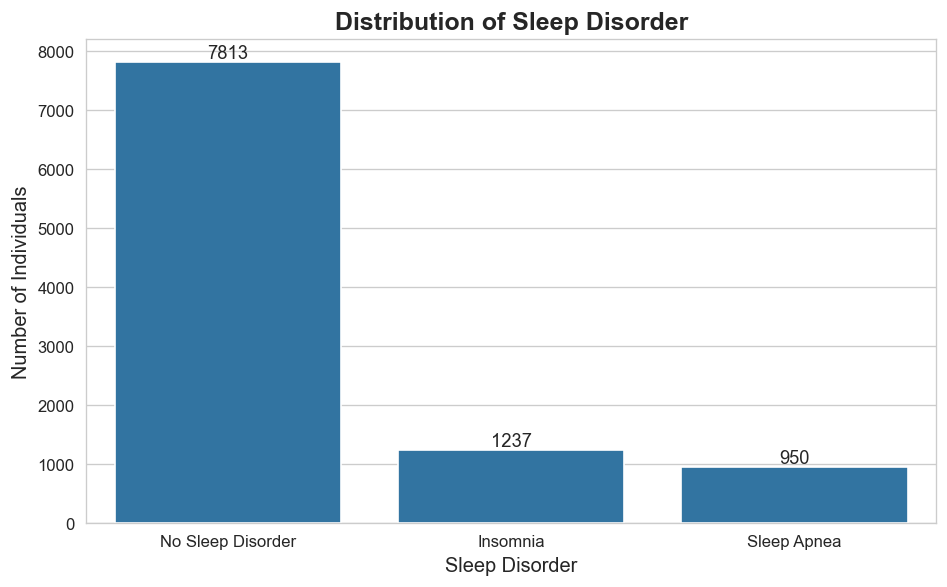

In [90]:
# Figure Size
plt.figure(figsize=(8,5))

# Count Plot
ax = sns.countplot(data=df, 
                   x="Sleep Disorder", 
                   order = df["Sleep Disorder"].value_counts().index
)

# Add Count Labels
for container in ax.containers:
    ax.bar_label(container, fontsize = 11) 

# Title & Labels
plt.title("Distribution of Sleep Disorder", fontsize = 15, weight = "bold")
plt.xlabel("Sleep Disorder", fontsize = 12)
plt.ylabel("Number of Individuals", fontsize = 12)

# Finalize Visualization
plt.tight_layout()
plt.show()

### Observations

<div style="font-size:16px; line-height:1.6;">

- The target variable shows a **class imbalance**, with **No Sleep Disorder (78.15%)** as the majority class, followed by **Insomnia (12.35%)** and **Sleep Apnea (9.50%)**.
- This imbalance may bias the model toward the majority class; therefore, **class-aware evaluation metrics and imbalance-handling techniques** will be considered during model development.
- The distribution provides a clear baseline for evaluating **multiclass model performance and minority-class recognition**.

</div>

### 4.2] Feature-wise Analysis

<div style="font-size:16px; line-height:1.6;">

Feature-wise analysis focuses on examining each predictor independently to understand its distribution, composition, and underlying characteristics. This analysis helps identify data patterns, variability, potential anomalies, and class frequencies before investigating relationships between multiple variables.

For better interpretability, the analysis is divided into **Numerical Feature Analysis** and **Categorical Feature Analysis**, allowing each feature type to be explored using appropriate visualization techniques.

</div>

### 4.2.1] Numerical Feature Analysis

<div style="font-size:16px; line-height:1.6;">

The numerical features are analyzed to understand their individual distributions, central tendency, spread, and overall variability. Histogram and density plots provide insights into the shape of each feature, helping identify skewness, concentration of observations, and potential irregularities that may require attention during the Data Preprocessing phase.

</div>


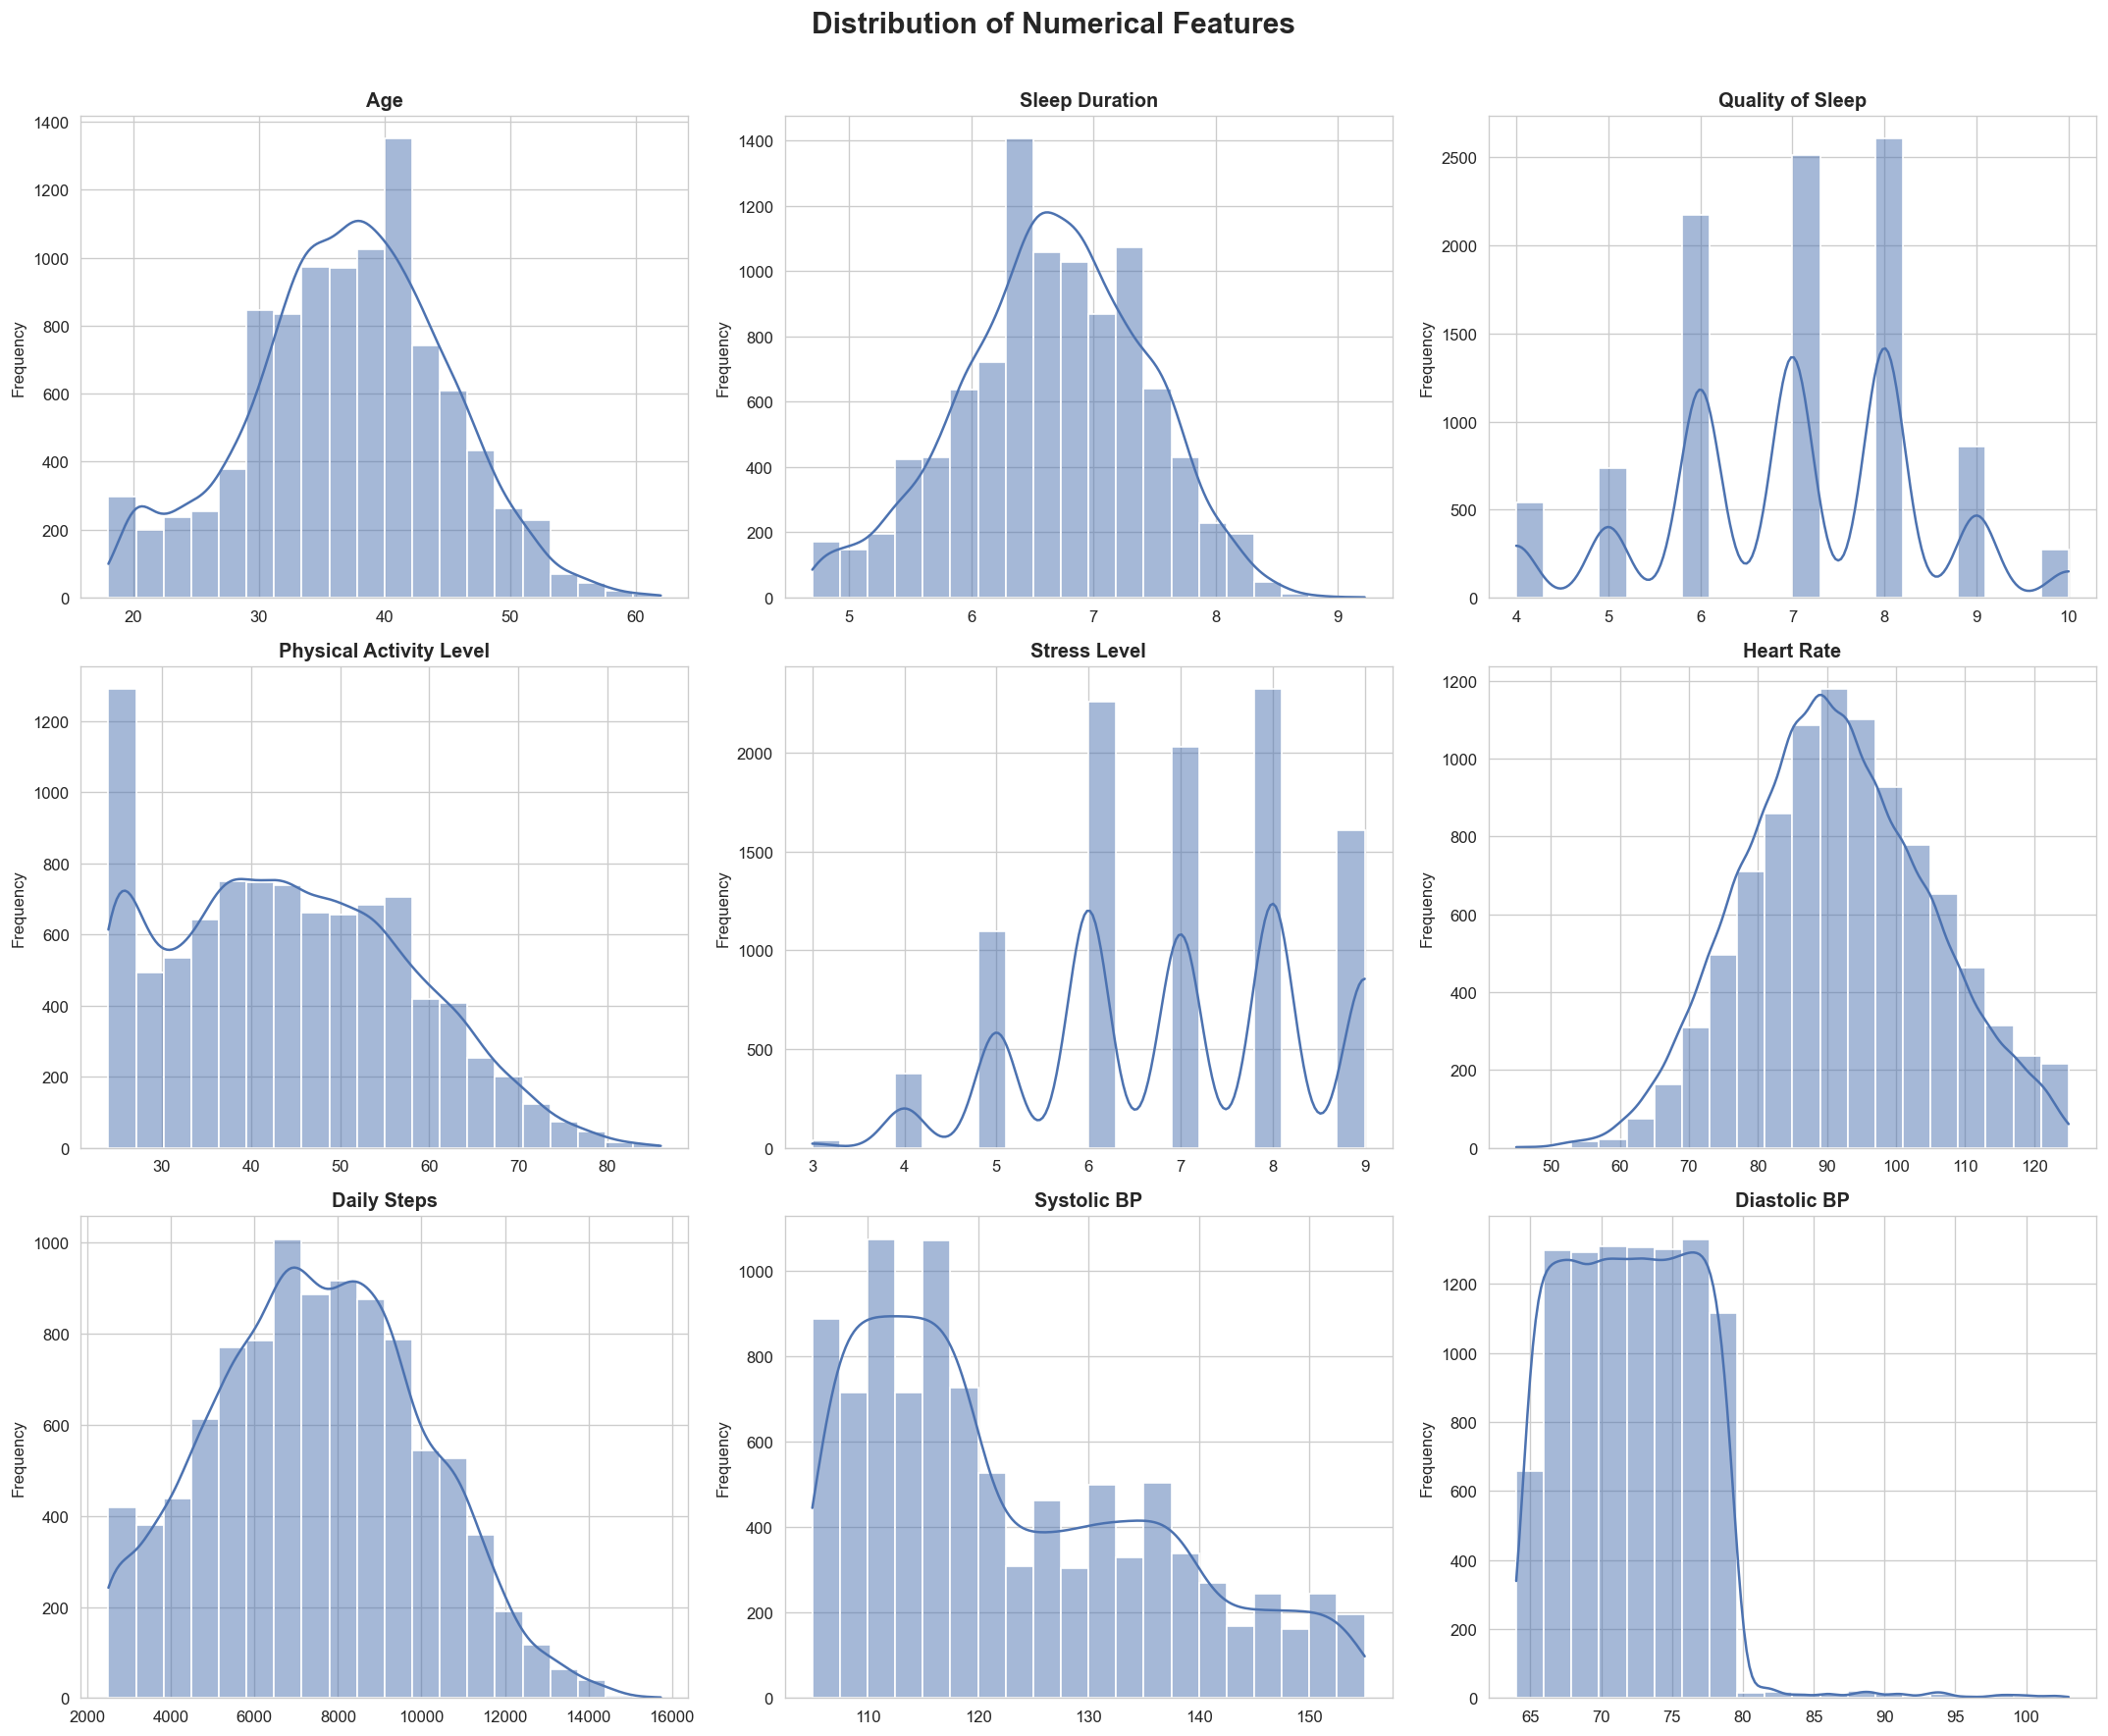

In [91]:
# Create Subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()


# Plot Numerical Feature Distributions
for ax, feature in zip(axes, numerical_features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        bins=20,
        ax=ax,
        color="#4C72B0"
    )


# Format Individual Feature Plots
    ax.set_title(feature, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")


# Add Overall Plot Title
plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18,
    fontweight="bold"
)


# Finalize Visualization
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

<div style="font-size:16px; line-height:1.6;">

### Insights

- **Age:** The distribution is concentrated around **30–45 years**, with fewer observations at the younger and older extremes.
- **Sleep Duration:** Most individuals report approximately **6–8 hours of sleep**, with a roughly bell-shaped distribution centered around **6.5–7 hours**.
- **Quality of Sleep:** Values are concentrated between **6 and 8**, with a discrete distribution and higher frequencies around **7–8**.
- **Physical Activity Level:** Activity levels are broadly distributed, with greater concentration around **30–60** and a gradual decline at higher levels.
- **Stress Level:** The feature has a **discrete distribution**, with observations concentrated particularly around **6–8**.
- **Heart Rate:** The distribution is approximately **bell-shaped**, centered around **85–100 BPM**, with relatively fewer extreme values.
- **Daily Steps:** Most observations fall between approximately **5,000–10,000 steps**, with a gradual decline toward higher activity levels.
- **Systolic BP:** Values are primarily concentrated around **105–120 mmHg**, with a gradual extension toward higher values.
- **Diastolic BP:** Most observations are concentrated around **65–80 mmHg**, with relatively fewer higher-value observations.

</div>

### 4.2.2] Categorical Feature Analysis

<div style="font-size:16px; line-height:1.6;">

Categorical feature analysis examines the frequency distribution of qualitative variables to understand the composition of different groups within the dataset. This analysis highlights dominant categories, identifies potential class imbalances among predictors, and provides insights into the demographic and lifestyle characteristics of the study population.

</div>


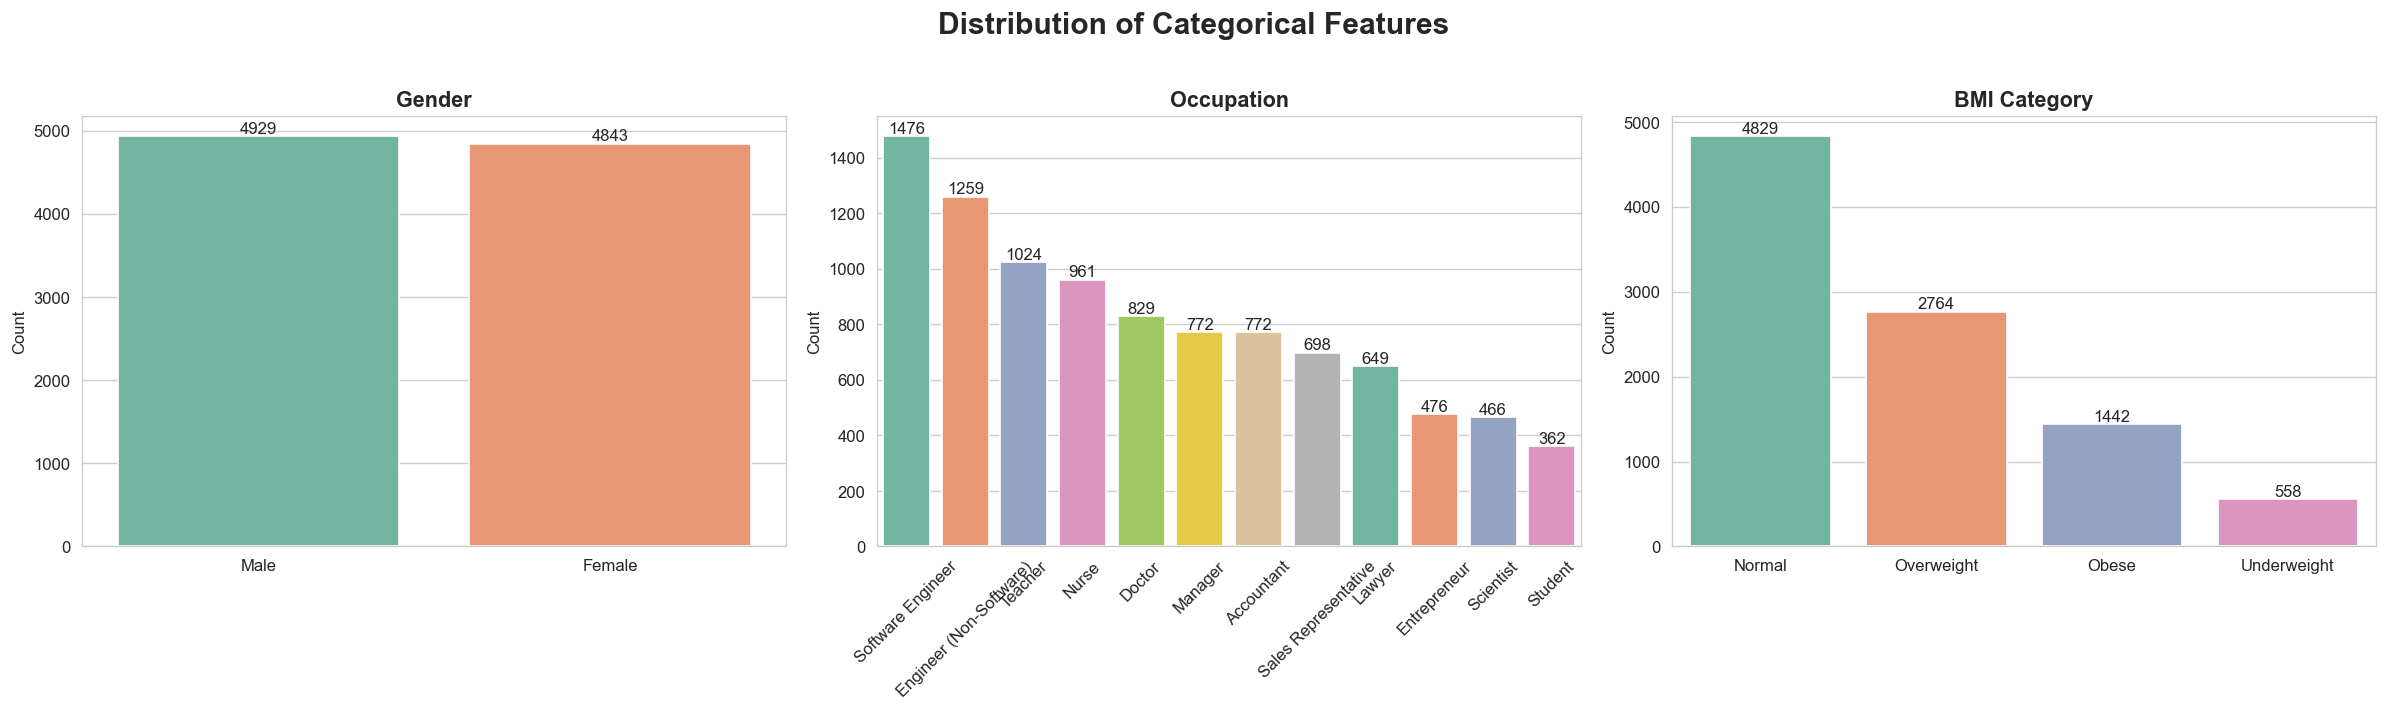

In [92]:
# Define Categorical Features
categorical_features = [
    "Gender",
    "Occupation",
    "BMI Category"
]


# Create Subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


# Plot Categorical Feature Distributions
for ax, feature in zip(axes, categorical_features):

    order = df[feature].value_counts().index

    sns.countplot(
        data=df,
        x=feature,
        order=order,
        ax=ax,
        palette="Set2"
    )


# Add Count Labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=10)


# Format Individual Feature Plots
    ax.set_title(feature, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")


# Rotate Occupation Labels
    if feature == "Occupation":
        ax.tick_params(axis="x", rotation=45)


# Add Overall Plot Title
plt.suptitle(
    "Distribution of Categorical Features",
    fontsize=18,
    fontweight="bold"
)


# Finalize Visualization
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<div style="font-size:16px; line-height:1.6;">

### Insights

- **Gender:** The distribution is nearly balanced, with **Male (4,929)** and **Female (4,843)** observations.
- **Occupation:** The dataset covers a diverse range of occupations, with **Software Engineers (1,476)** among the more represented groups, while **Student (362)** has the lowest representation.
- **BMI Category:** **Normal (4,829)** is the dominant category, followed by **Overweight (2,764)**, **Obese (1,442)**, and **Underweight (558)**.

</div>

### 4.3] Relationship Analysis

<div style="font-size:16px; line-height:1.6;">

Relationship analysis explores how different features interact with each other and with the target variable. This phase aims to identify meaningful associations, trends, and patterns that may influence sleep disorders. The insights obtained help validate domain knowledge, support feature selection, and improve the interpretability of the predictive model.

</div>

### 4.3.1] Numerical Features vs Target

<div style="font-size:16px; line-height:1.6;">

This analysis examines how numerical features vary across different sleep disorder categories. Comparing feature distributions against the target variable helps identify characteristics that distinguish each class and reveals variables that may possess strong predictive power.

</div>


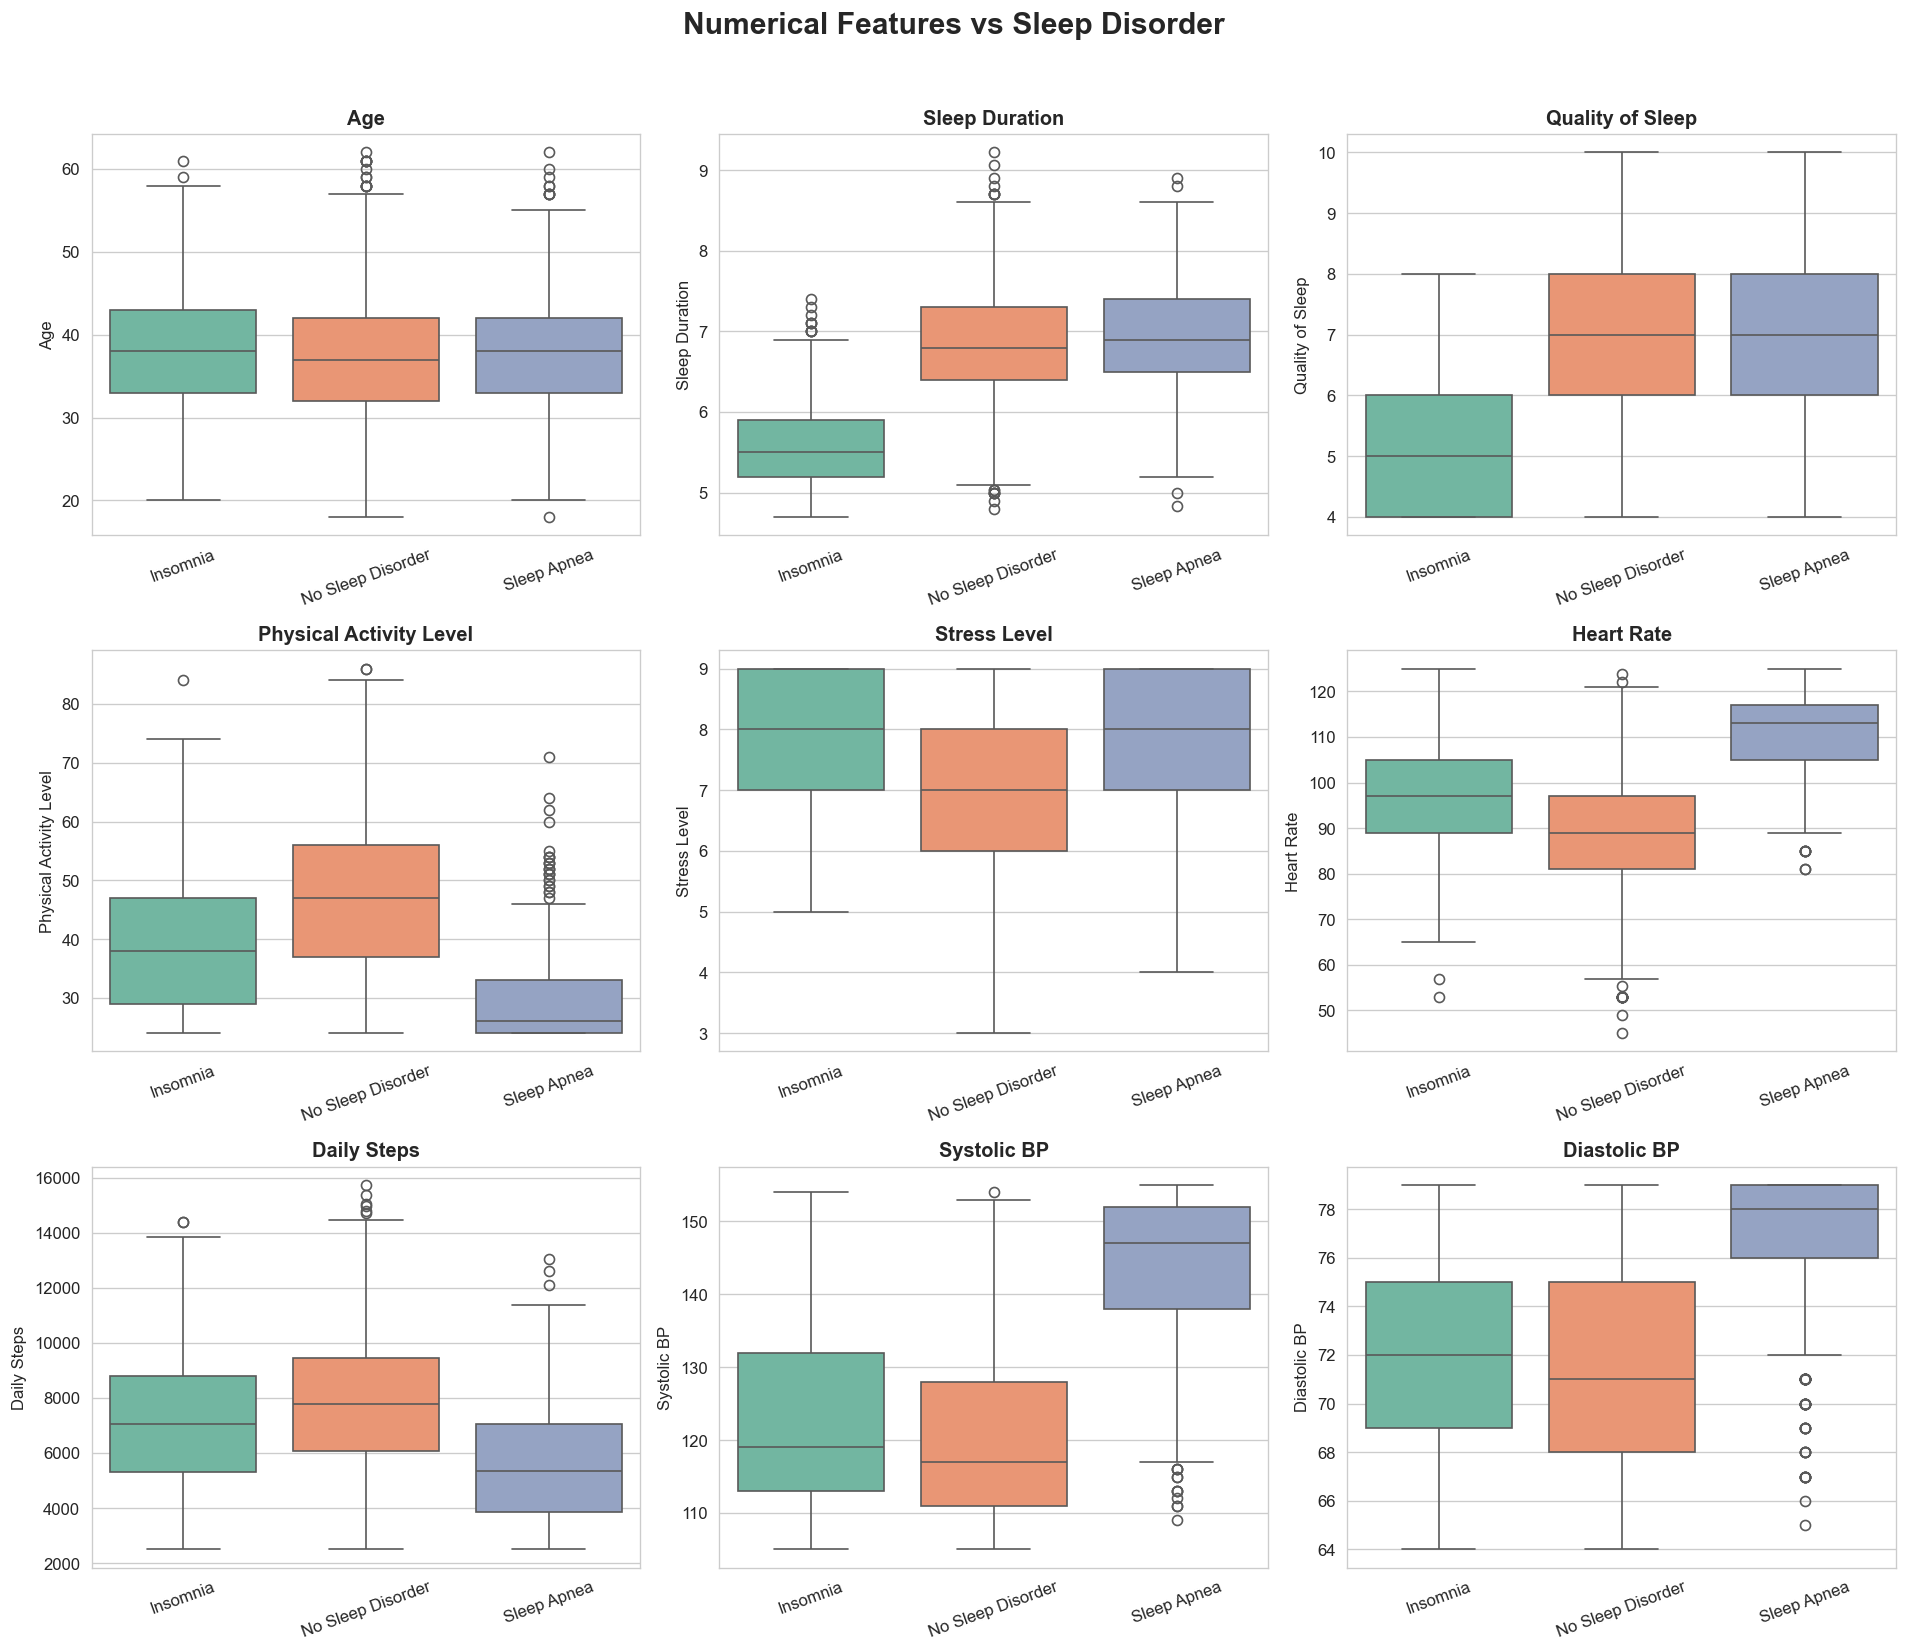

In [ ]:
# Define Original Numerical Features
numerical_features = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Systolic BP',
    'Diastolic BP'
]


# Prepare Data for Numerical Feature vs Target Analysis
plot_df = df[numerical_features + ["Sleep Disorder"]].dropna()


# Create Subplots
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()


# Plot Numerical Features Against Sleep Disorder
for ax, feature in zip(axes, numerical_features):

    sns.boxplot(
        data=plot_df,
        x="Sleep Disorder",
        y=feature,
        hue="Sleep Disorder",
        palette="Set2",
        legend=False,
        ax=ax
    )

    ax.set_title(feature, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(feature)

    ax.tick_params(axis="x", rotation=20)


# Add Overall Plot Title
fig.suptitle(
    "Numerical Features vs Sleep Disorder",
    fontsize=18,
    fontweight="bold"
)


# 4.6] Finalize Visualization

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
plt.close()

<div style="font-size:16px; line-height:1.6;">

### Insights

- **Age:** Median age is broadly similar across classes, with **No Sleep Disorder** showing slightly greater variability.
- **Sleep Duration:** **Insomnia** shows the lowest median sleep duration, while **Sleep Apnea** shows the highest.
- **Quality of Sleep:** **Insomnia** has noticeably lower sleep quality, while **No Sleep Disorder** and **Sleep Apnea** show higher and similar median values.
- **Physical Activity Level:** **Sleep Apnea** shows the lowest median activity level, while **No Sleep Disorder** has the highest.
- **Stress Level:** **Insomnia** and **Sleep Apnea** show higher median stress levels than **No Sleep Disorder**.
- **Heart Rate:** **Sleep Apnea** has the highest median heart rate, while **No Sleep Disorder** shows the lowest.
- **Daily Steps:** **No Sleep Disorder** has the highest median daily steps, while **Sleep Apnea** has the lowest.
- **Systolic BP:** **Sleep Apnea** shows substantially higher median systolic blood pressure compared with the other classes.
- **Diastolic BP:** **Sleep Apnea** also has the highest median diastolic blood pressure, while the other two classes show lower and similar medians.

</div>

### 4.3.2] Categorical Features vs Target

<div style="font-size:16px; line-height:1.6;">

This analysis examines how categorical features are distributed across different sleep disorder categories. Comparing demographic and lifestyle-related categories with the target variable helps identify potential associations, dominant patterns, and categorical factors that may influence the occurrence of sleep disorders.

</div>


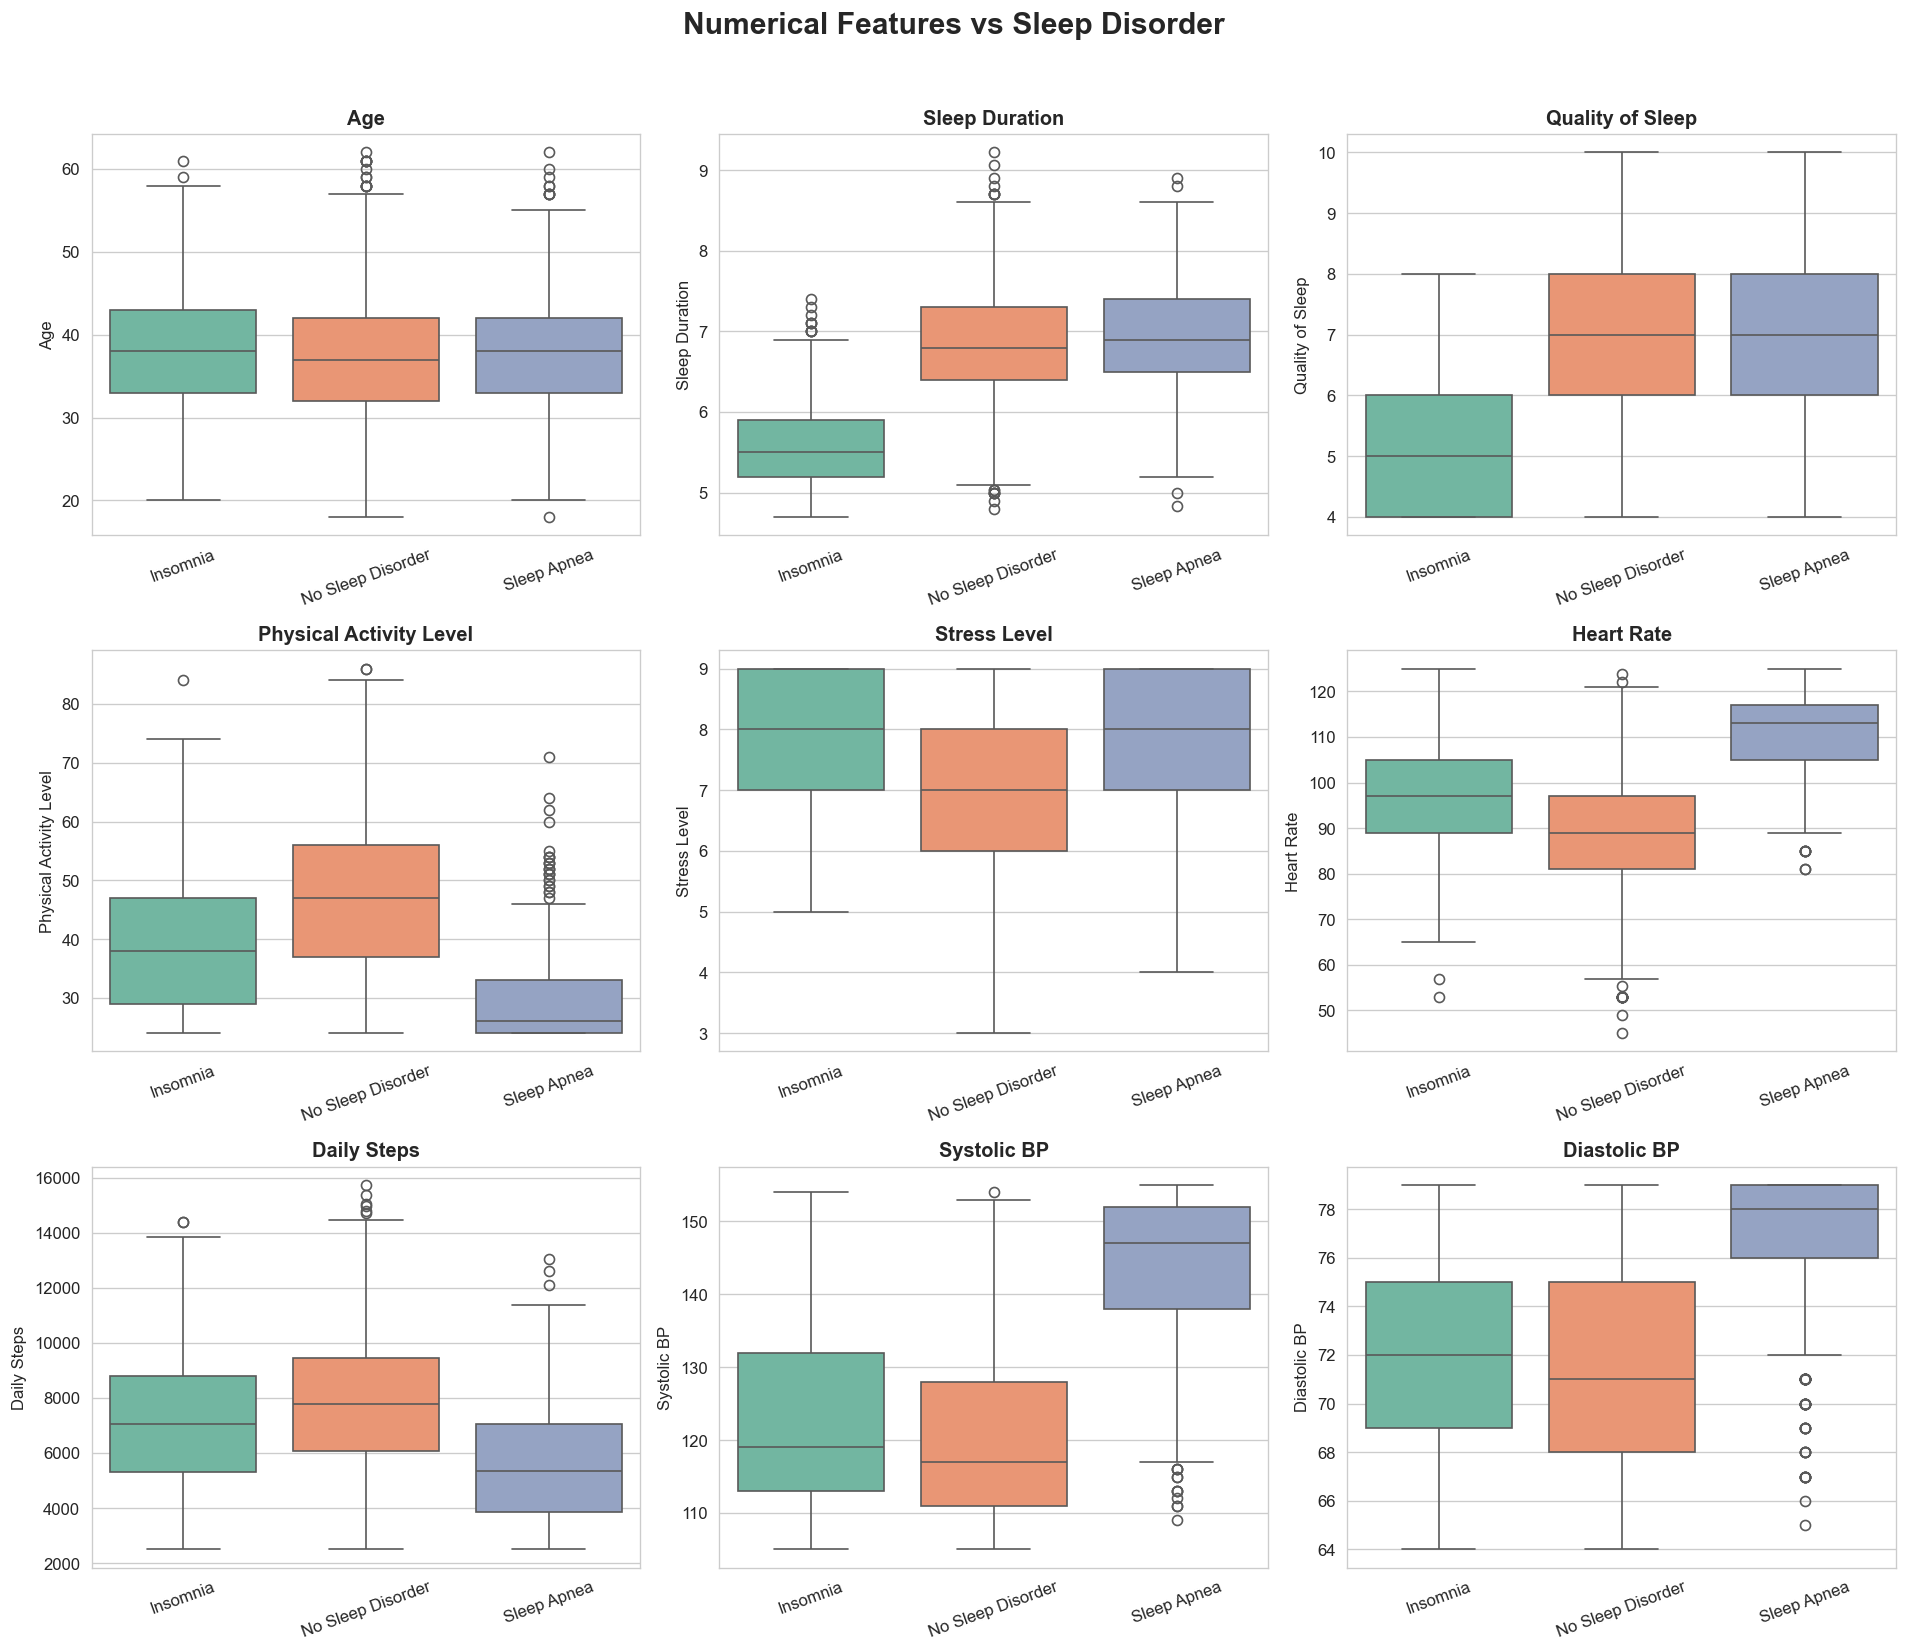

In [ ]:
# Prepare Data for Numerical Feature vs Target Analysis
plot_df = df[numerical_features + ["Sleep Disorder"]].dropna()


# Create Subplots
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()


# Plot Numerical Features Against Sleep Disorder
for ax, feature in zip(axes, numerical_features):

    sns.boxplot(
        data=plot_df,
        x="Sleep Disorder",
        y=feature,
        hue="Sleep Disorder",
        palette="Set2",
        legend=False,
        ax=ax
    )

    ax.set_title(feature, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(feature)

    ax.tick_params(axis="x", rotation=20)


# Add Overall Plot Title
fig.suptitle(
    "Numerical Features vs Sleep Disorder",
    fontsize=18,
    fontweight="bold"
)


# Finalize Visualization
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
plt.close()

<div style="font-size:16px; line-height:1.6;">

### Insights

### Gender
- **No Sleep Disorder** is the dominant class for both **Male** and **Female**, with relatively similar distributions across genders.
- **Gender** shows limited variation across sleep disorder categories.

### Occupation
- Sleep disorder counts vary across occupations, with **Doctor, Nurse, and Lawyer** showing relatively higher occurrences of **Insomnia** and **Sleep Apnea**.
- This variation suggests that **Occupation** may provide useful predictive information.

### BMI Category
- **No Sleep Disorder** is most prominent among individuals with **Normal BMI**.
- **Sleep Apnea** shows a noticeably higher occurrence among **Obese** individuals, while **Overweight** individuals also show increased sleep disorder counts compared with the **Normal** category.
- **Underweight** has comparatively fewer observations across all classes.

### Overall Insight
- **BMI Category** shows the clearest visual association with sleep disorder status, followed by **Occupation**, while **Gender** shows comparatively limited variation.

</div>

### 4.3.3] Numerical Features vs Numerical Features

<div style="font-size:16px; line-height:1.6;">

This analysis examines the relationships among numerical features to identify potential linear associations, underlying trends, and dependencies. Understanding these relationships helps detect multicollinearity, supports feature selection, and provides insights into how physiological and lifestyle variables interact with one another.

</div>

### A] Correlation HeatMap


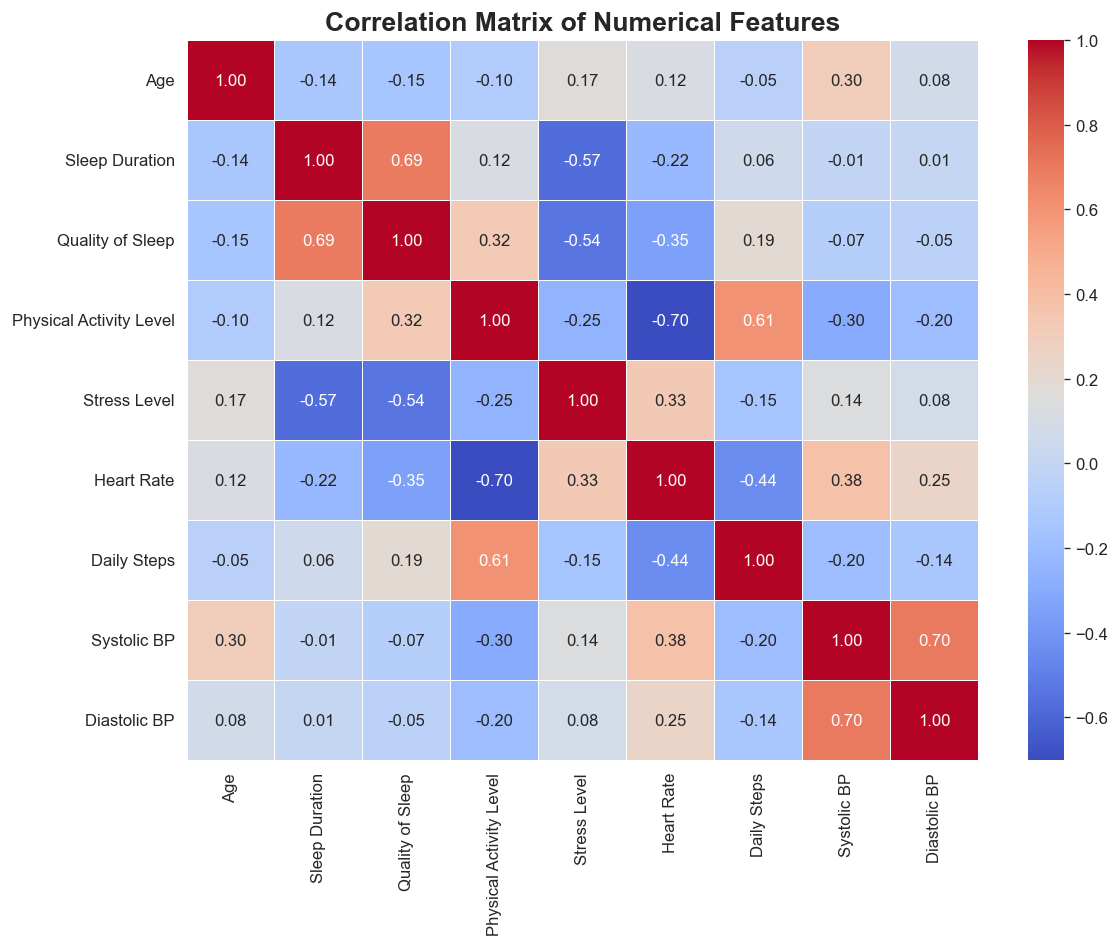

In [ ]:
# Calculate the correlation matrix for numerical features
corr_matrix = df[numerical_features].corr()

# Set the figure size
plt.figure(figsize=(10,8))

# Create the correlation heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# Add a title to the heatmap
plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

# Adjust the layout
plt.tight_layout()

# Display the heatmap
plt.show()

<div style="font-size:16px; line-height:1.6;">

### Insights

- **Sleep Duration** shows a **strong positive correlation** with **Quality of Sleep (r = 0.69)** and a **moderate negative correlation** with **Stress Level (r = -0.57)**, indicating that longer sleep duration is associated with better sleep quality and lower stress.

- **Physical Activity Level** has a **strong positive correlation** with **Daily Steps (r = 0.61)** and a **strong negative correlation** with **Heart Rate (r = -0.70)**, indicating a relationship between physical activity, daily movement, and heart rate.

- **Systolic BP** and **Diastolic BP** show a **strong positive correlation (r = 0.70)**, reflecting a close relationship between the two blood pressure measurements.

- **Quality of Sleep** also shows a **moderate negative correlation** with **Stress Level (r = -0.54)**, indicating that higher stress levels are associated with lower reported sleep quality.

- Overall, the dataset does not exhibit **widespread strong multicollinearity**, although a few feature pairs show notable correlations that should be considered during model development.

</div>

### B] Pair Plot (Scatterplot Matrix)


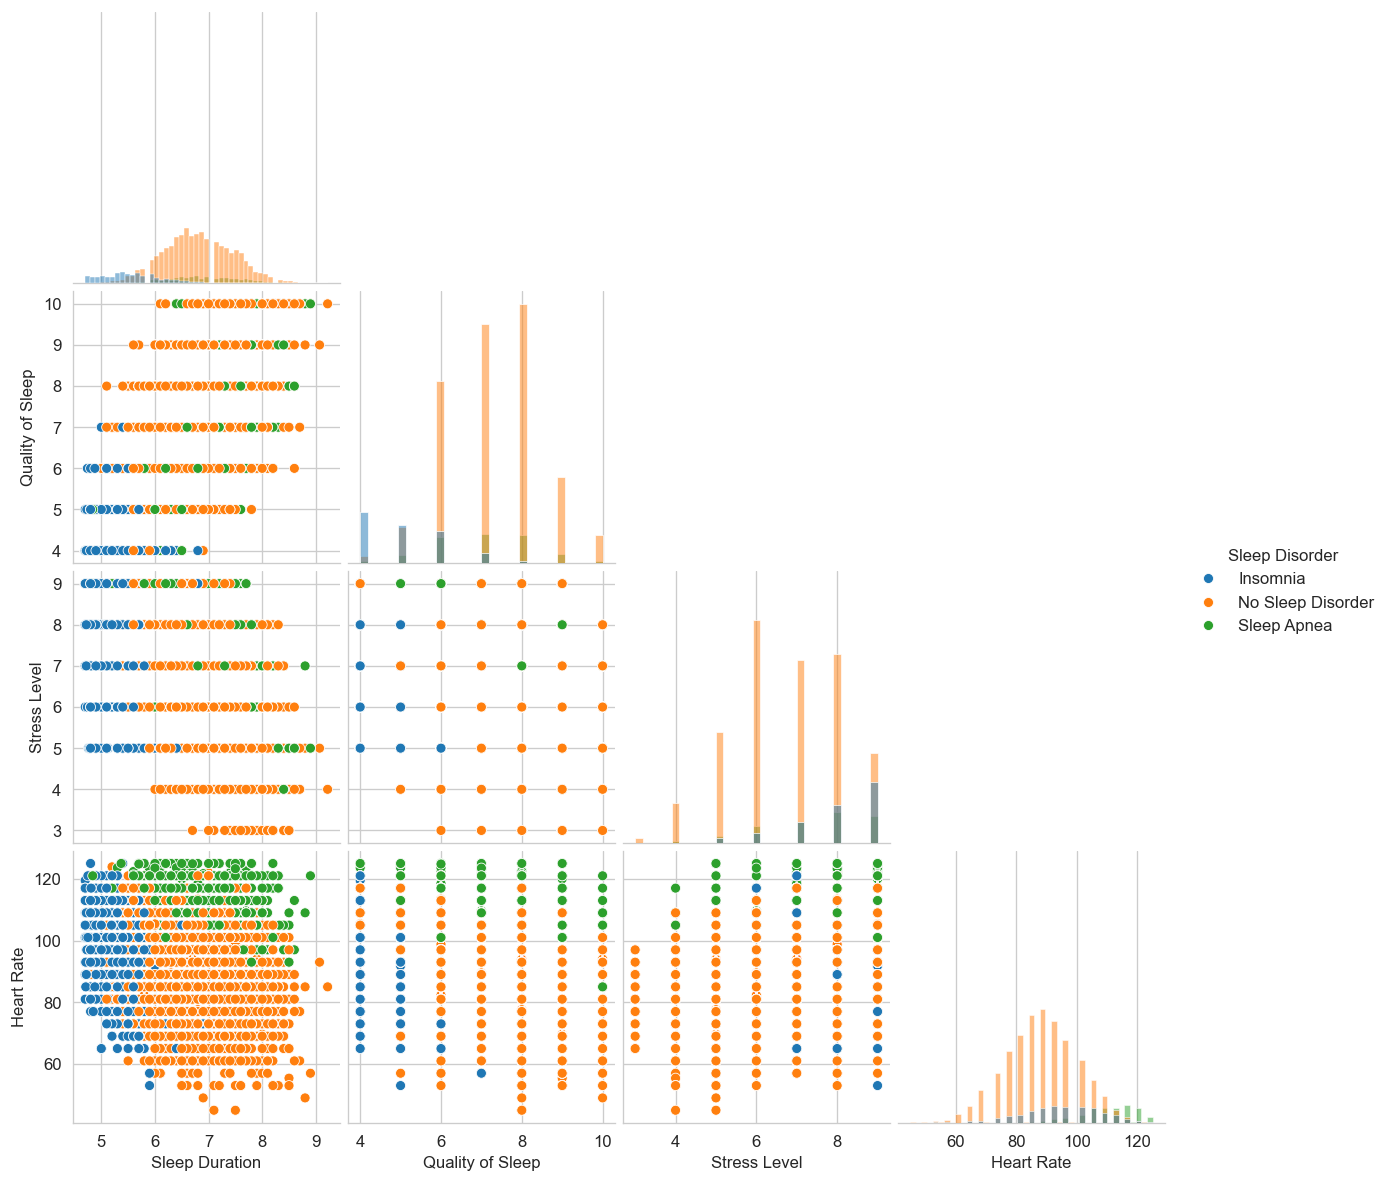

In [ ]:
# Select the features for the pair plot
selected_features = [
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Heart Rate",
    "Sleep Disorder"
]

# Create a pair plot to visualize relationships between selected features
sns.pairplot(
    df[selected_features],
    hue="Sleep Disorder",
    diag_kind="hist",
    corner=True
)

# Display the pair plot
plt.show()

<div style="font-size:16px; line-height:1.6;">

### Insights

- **Sleep Duration** and **Quality of Sleep** show a clear positive relationship, with longer sleep duration generally associated with higher sleep quality.

- **Stress Level** shows an inverse relationship with both **Sleep Duration** and **Quality of Sleep**, indicating that higher stress levels are generally associated with shorter and lower-quality sleep.

- **Heart Rate** shows noticeable variation across sleep disorder categories, with **Sleep Apnea** generally associated with higher heart rates, while **No Sleep Disorder** tends to show lower values.

- The three sleep disorder categories exhibit considerable overlap across the numerical features, although some separation is visible in **Sleep Duration, Quality of Sleep, Stress Level, and Heart Rate**.

- Overall, the pairwise relationships indicate that **Sleep Duration, Quality of Sleep, Stress Level, and Heart Rate** provide useful predictive information, while the class overlap suggests that multiple features will be required for effective classification.

</div>

### 4.4] Outlier Analysis

<div style="font-size:16px; line-height:1.6;">

Outlier analysis was performed to identify unusually high or low observations within the numerical features using the **Interquartile Range (IQR) method**.

- The analysis focuses on numerical variables while excluding **Person ID**, as it is an identifier rather than a predictive feature.
- The IQR method identifies observations outside the range defined by **Q1 − 1.5 × IQR** and **Q3 + 1.5 × IQR**.
- Box plots are used to visually examine the distribution and presence of potential outliers.
- Detected outliers are treated as **potential observations requiring investigation**, rather than automatically being considered erroneous values.
- In this dataset, extreme observations may represent genuine variations in sleep, activity, cardiovascular measurements, or other health-related characteristics.
- Therefore, outlier treatment will be considered during **Data Preprocessing** based on statistical evidence, domain relevance, and model requirements.

**Key Objective:** Identify potential extreme observations without altering the dataset during EDA.

</div>

### 4.4.1] IQR-Based Outlier Detection

<div style="font-size:16px; line-height:1.6;">

- Identified potential outliers across numerical features using the **IQR method**.
- Calculated the **outlier count and percentage** for each feature.
- Excluded **Person ID** as it is an identifier rather than an analytical feature.

</div>


In [ ]:
# Numerical features excluding Person ID
numerical_features = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Systolic BP',
    'Diastolic BP'
]

# Store outlier analysis results
outlier_summary = []

# Calculate outliers for each numerical feature
for col in numerical_features:

    # Remove missing values for IQR calculation
    data = df[col].dropna()

    # Calculate the first quartile
    Q1 = data.quantile(0.25)

    # Calculate the third quartile
    Q3 = data.quantile(0.75)

    # Calculate the interquartile range
    IQR = Q3 - Q1

    # Calculate the lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify values outside the calculated bounds
    outliers = data[
        (data < lower_bound) |
        (data > upper_bound)
    ]

    # Count the number of outliers
    outlier_count = len(outliers)

    # Count the total number of non-missing values
    total_count = len(data)

    # Calculate the percentage of outliers
    outlier_percentage = (outlier_count / total_count) * 100

    # Store the outlier statistics for the feature
    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier %': round(outlier_percentage, 2)
    })

# Convert the outlier summary into a DataFrame
outlier_summary_df = pd.DataFrame(outlier_summary)

# Display the outlier summary
outlier_summary_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Age,32.0,42.0,10.0,17.0,57.0,31,0.32
1,Sleep Duration,6.2,7.2,1.0,4.7,8.7,7,0.07
2,Quality of Sleep,6.0,8.0,2.0,3.0,11.0,0,0.00
3,Physical Activity Level,34.0,54.0,20.0,4.0,84.0,3,0.03
4,Stress Level,6.0,8.0,2.0,3.0,11.0,0,0.00
5,Heart Rate,81.0,101.0,20.0,51.0,131.0,4,0.04
6,Daily Steps,5650.5,9248.5,3598.0,253.5,14645.5,6,0.06
7,Systolic BP,112.0,133.0,21.0,80.5,164.5,0,0.00
8,Diastolic BP,68.0,76.0,8.0,56.0,88.0,68,0.70


### Key Insights

<div style="font-size:16px; line-height:1.6;">

- **Diastolic BP** shows the highest outlier proportion (**0.70%**), followed by **Age (0.32%)** and **Sleep Duration (0.07%)**.
- **Daily Steps (0.06%)**, **Heart Rate (0.04%)**, and **Physical Activity Level (0.03%)** show only a small number of potential outliers.
- **Quality of Sleep, Stress Level, and Systolic BP** show **0% IQR-based outliers**.
- Overall, all features have **less than 1% potential outliers**, indicating limited extreme-value presence.

</div>

### 4.4.2] Visual Outlier Analysis

<div style="font-size:16px; line-height:1.6;">

- **Box plots** were used to visually examine the distribution and potential extreme observations across the numerical features.
- Observations appearing beyond the whiskers represent values that may require further investigation under the IQR criterion.
- The visual analysis complements the numerical IQR assessment by revealing the **spread, central tendency, variability, and concentration of extreme values**.
- Potential outliers are retained during EDA and will be evaluated during **Data Preprocessing** before deciding whether treatment is statistically and domain-wise justified.

</div>


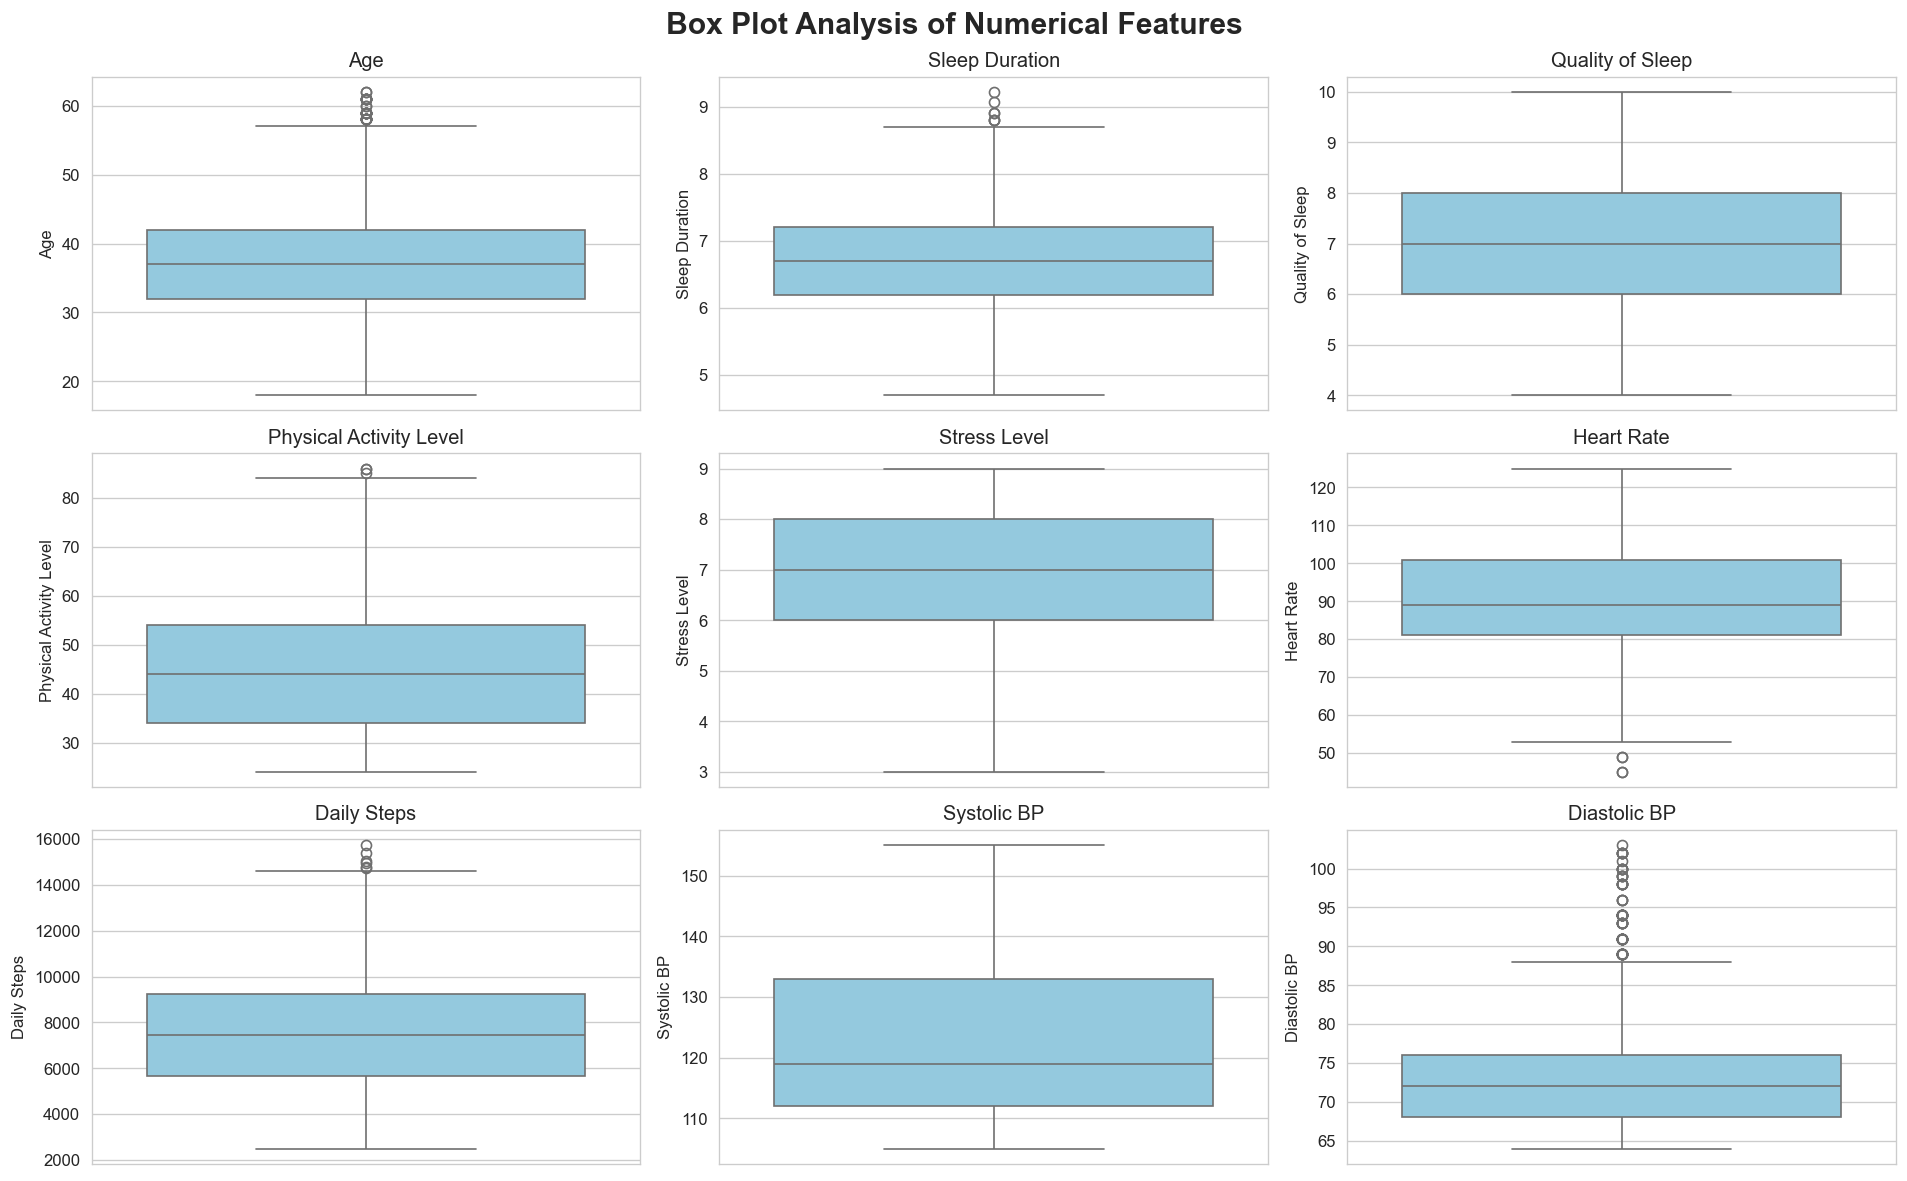

In [ ]:
# Set the figure size
plt.figure(figsize=(16, 10))

# Create a box plot for each numerical feature
for i, col in enumerate(numerical_features, 1):

    # Create a subplot in a 3x3 grid
    plt.subplot(3, 3, i)

    # Create the box plot for the feature
    sns.boxplot(
        y=df[col],
        color='skyblue'
    )

    # Add the feature name as the title
    plt.title(col)

    # Label the y-axis with the feature name
    plt.ylabel(col)

# Add an overall title to the figure
plt.suptitle(
    'Box Plot Analysis of Numerical Features',
    fontsize=18,
    fontweight='bold'
)

# Adjust the layout
plt.tight_layout()

# Display the box plots
plt.show()

### 4.5] EDA Summary & Key Insights

<div style="font-size:16px; line-height:1.6;">

- **Target Distribution:** The dataset shows a **class imbalance**, with **No Sleep Disorder (78.15%)** as the majority class, followed by **Insomnia (12.35%)** and **Sleep Apnea (9.50%)**.

- **Numerical Features:** **Sleep Duration, Quality of Sleep, Stress Level, Physical Activity Level, Heart Rate, and Blood Pressure** show noticeable distributional differences across sleep disorder classes.

- **Categorical Features:** **BMI Category** and **Occupation** show variation across target classes, while **Gender** provides comparatively weaker visual separation.

- **Feature Relationships:** **Sleep Duration and Quality of Sleep** show a positive association, while **Stress Level** is negatively associated with sleep-related measures. **Physical Activity Level and Daily Steps** exhibit a strong positive correlation.

- **Outlier Assessment:** Potential IQR-based outliers are limited, with **less than 1%** detected across every numerical feature; therefore, they require validation rather than automatic removal.

- **Overall EDA Finding:** The dataset exhibits meaningful **sleep, lifestyle, demographic, and physiological patterns** across target classes, supporting a multiclass classification approach based on **multiple features jointly**.

</div>

<div style="font-size:16px; line-height:1.6;">


### Phase 5] Feature Engineering

Feature engineering is performed to derive meaningful relationships from the existing health and lifestyle variables. Three domain-relevant features are created to provide additional information for distinguishing between **No Sleep Disorder, Insomnia, and Sleep Apnea**.

The engineered features are derived from existing predictors without using the target variable.

</div>

<div style="font-size:16px; line-height:1.6;">

### 5.1] Pulse Pressure

**Pulse Pressure** represents the difference between systolic and diastolic blood pressure and provides an additional representation of an individual's blood pressure profile.

**Formula:**

$$
\text{Pulse Pressure} = \text{Systolic BP} - \text{Diastolic BP}
$$

</div>


<div style="font-size:16px; line-height:1.6;">

### 5.2] Sleep Quality Index

The **Sleep Quality Index** combines sleep duration and reported sleep quality into a single standardized indicator. It provides a consolidated representation of an individual's overall sleep profile.

**Formula:**

$$
\text{Sleep Quality Index}
=
\frac{
\frac{\text{Sleep Duration}}{24}
+
\frac{\text{Quality of Sleep}}{10}
}{2}
$$

Higher values indicate a relatively stronger overall sleep profile.

</div>

<div style="font-size:16px; line-height:1.6;">

### 5.3] Stress-Sleep Interaction

The **Stress-Sleep Interaction** captures the combined effect of stress level and sleep duration. It provides an additional representation of the relationship between these two sleep-related factors.

**Formula:**

$$
\text{Stress-Sleep Interaction}
=
\text{Stress Level} \times \text{Sleep Duration}
$$

</div>

<div style="font-size:16px; line-height:1.6;">

### 5.4] Engineered Feature Validation

The newly engineered features are validated to ensure that the transformations have been applied correctly and that no invalid or infinite values have been introduced.

</div>


In [99]:
# Create Pulse Pressure
df["Pulse Pressure"] = df["Systolic BP"] - df["Diastolic BP"]

# Verify the engineered feature
df[["Systolic BP", "Diastolic BP", "Pulse Pressure"]].head()

# Create Sleep Quality Index
sleep_duration_score = df["Sleep Duration"] / 24
sleep_quality_score = df["Quality of Sleep"] / 10

df["Sleep Quality Index"] = (
    (sleep_duration_score + sleep_quality_score) / 2
).round(3)

# Verify the engineered feature
df[[
    "Sleep Duration",
    "Quality of Sleep",
    "Sleep Quality Index"
]].head()

# Create Stress-Sleep Interaction
df["Stress-Sleep Interaction"] = (
    df["Stress Level"] * df["Sleep Duration"]
)

# Verify the engineered feature
df[[
    "Stress Level",
    "Sleep Duration",
    "Stress-Sleep Interaction"
]].head()

# Select engineered features
engineered_features = [
    "Pulse Pressure",
    "Sleep Quality Index",
    "Stress-Sleep Interaction"
]

# Summary statistics
df[engineered_features].describe()


,Pulse Pressure,Sleep Quality Index,Stress-Sleep Interaction
count,9738.000000,9438.000000,9467.000000
mean,50.539844,0.488238,45.920916
std,10.515359,0.080865,7.939512
min,28.000000,0.298000,20.100000
25%,42.000000,0.433000,40.200000
50%,47.000000,0.492000,46.200000
75%,58.000000,0.546000,51.800000
max,80.000000,0.692000,69.300000


### 5.5] Engineered Feature Analysis — Key Insights



In [ ]:
# Group the data by Sleep Disorder and calculate summary statistics
df.groupby("Sleep Disorder")[

    ["Pulse Pressure",
     "Sleep Quality Index",
     "Stress-Sleep Interaction"]

].agg(["mean", "median", "std"])

Pulse Pressure                  Sleep Quality Index         \
                            mean median       std                mean median   
Sleep Disorder                                                                 
Insomnia               50.110191   48.0  9.700419            0.368030  0.362   
No Sleep Disorder      48.684487   46.0  9.140695            0.506253  0.500   
Sleep Apnea            66.491285   69.0  8.557422            0.497458  0.496   

                            Stress-Sleep Interaction                   
                        std                     mean median       std  
Sleep Disorder                                                         
Insomnia           0.058127                44.766318   45.0  7.299465  
No Sleep Disorder  0.067778                45.431393   45.6  7.843690  
Sleep Apnea        0.070783                51.496007   52.0  7.331001

<div style="font-size:16px; line-height:1.6;">

- **Pulse Pressure** shows strong separation for **Sleep Apnea**, with a substantially higher class mean (**66.49**) compared with Insomnia (**50.11**) and No Sleep Disorder (**48.68**).
- **Sleep Quality Index** strongly distinguishes **Insomnia**, with a lower mean (**0.368**) compared with No Sleep Disorder (**0.506**) and Sleep Apnea (**0.497**).
- **Stress-Sleep Interaction** shows additional separation for **Sleep Apnea** (**51.50**) compared with Insomnia (**44.77**) and No Sleep Disorder (**45.43**).
- Overall, the engineered features provide **complementary class-separating signals** and will be retained for subsequent model validation.

</div>

In [101]:
# Check missing values
df[engineered_features].isna().sum()

Pulse Pressure              262
Sleep Quality Index         562
Stress-Sleep Interaction    533
dtype: int64

### Phase 6] Data Preprocessing

<div style="font-size:16px; line-height:1.6;">

This phase prepares the dataset for model development using a **leakage-free and reproducible preprocessing pipeline**. Numerical and categorical features are handled separately through imputation, encoding, and scaling, with all preprocessing parameters learned exclusively from the training data.

</div>

### 6.1] Separate Features and Target

<div style="font-size:16px; line-height:1.6;">

The dataset is separated into **input features (X)** and the **target variable (y)** to prepare the data for supervised model development.

</div>

### 6.2] Train-Test Split

<div style="font-size:16px; line-height:1.6;">

The dataset is divided into training and testing sets using a **stratified 80:20 split** to preserve the target-class distribution across both datasets.

</div>

### 6.3] Feature Type Identification

<div style="font-size:16px; line-height:1.6;">

Numerical and categorical features are identified separately to apply **feature-specific preprocessing** within the pipeline.

</div>

### 6.4] Build Complete Preprocessing Pipeline — Numerical, Categorical & Column Transformer

In this stage, we build a complete preprocessing pipeline by handling missing values and scaling numerical features, imputing and encoding categorical features, and combining both pipelines using `ColumnTransformer`. This ensures that all preprocessing steps are applied consistently and helps prevent data leakage when the pipeline is fitted only on the training data.

### 6.5] Apply Preprocessing Pipeline

<div style="font-size:16px; line-height:1.6;">

The preprocessing pipeline is fitted **only on the training data** and then applied to both training and testing data to ensure a consistent and leakage-free transformation.

</div>


In [ ]:
# Separate Features and Target
X = df.drop("Sleep Disorder", axis=1)
y = df["Sleep Disorder"]

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size = 0.2, 
    random_state = 42, 
    stratify = y)

# Feature Type Identification
numerical_features = X_train.select_dtypes(
    include = ["int64","float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include = ["object"]
).columns.tolist()

print("Numerical Features :")
print(numerical_features)
print("Categorical Features :")
print(categorical_features)

# Build Complete Preprocessing Pipeline
#      Stage 1: Numerical Pipeline
#      Stage 2: Categorical Pipeline
#      Stage 3: Column Transformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Stage 1: Numerical Pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "mean")),
    ("scaler", StandardScaler())
])

# Stage 2: Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown = "ignore")) 
])

# Stage 3: Combine Numerical & Categorical Pipelines
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Apply Preprocessing Pipeline

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape :", X_train_processed.shape )
print("Processed Testing Shape :", X_test_processed.shape)


Numerical Features :
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP', 'Pulse Pressure', 'Sleep Quality Index', 'Stress-Sleep Interaction']
Categorical Features :
['Gender', 'Occupation', 'BMI Category']
Processed Training Shape : (8000, 30)
Processed Testing Shape : (2000, 30)


### Phase 7] Model Development & Selection

Develop, validate, and compare classification models using
stratified cross-validation.

The modeling process evaluates multiple algorithms and two approaches
for handling class imbalance: class weighting and SMOTE.

Model selection is based primarily on Macro F1, supported by balanced
accuracy, precision, recall, and ROC-AUC.

The test set remains completely untouched until final model evaluation.

### 7.1] Target Encoding

Convert the multiclass target labels into explicit numeric class labels.

The mapping is fixed so that the class meaning remains consistent
throughout model training, evaluation, and interpretation.

0 = No Sleep Disorder
1 = Insomnia
2 = Sleep Apnea

### 7.2] Candidate Model Definition

Define the candidate classification models for comparison.

Class weighting is used for Logistic Regression, Decision Tree,
Random Forest, and SVM to account for class imbalance.

XGBoost is configured explicitly for multiclass classification and
does not use binary-only scale_pos_weight.

### 7.3] Cross-Validation Strategy

Use Stratified K-Fold cross-validation to preserve the class distribution
across all validation folds.

Five folds provide a reliable balance between computational cost and
performance estimation.

All preprocessing steps will be fitted independently inside each fold
through the modeling pipeline.

### 7.4] Evaluation Metrics

Evaluate models using multiple complementary metrics.

Macro F1 is the primary metric because it gives equal importance to all
three classes.

Balanced Accuracy, Macro Precision, and Macro Recall provide additional
class-level performance information.

ROC-AUC measures the model's ability to distinguish between classes.

Weighted F1 and Accuracy are retained as supporting metrics.


In [ ]:
# Target Encoding
target_mapping = {
    "No Sleep Disorder": 0,
    "Insomnia": 1,
    "Sleep Apnea": 2
}

y_train_encoded = y_train.map(target_mapping)
y_test_encoded = y_test.map(target_mapping)

print("Target Mapping:")
print(target_mapping)

print("\nTraining Class Distribution:")
print(y_train_encoded.value_counts().sort_index())

print("\nTesting Class Distribution:")
print(y_test_encoded.value_counts().sort_index())

# Candidate Model Definition
from sklearn.ensemble import RandomForestClassifier

models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )
}

# Cross-Validation Strategy
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-Validation Strategy:")
print(cv)

# Evaluation Metrics
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "roc_auc": "roc_auc_ovr"
}


Target Mapping:
{'No Sleep Disorder': 0, 'Insomnia': 1, 'Sleep Apnea': 2}

Training Class Distribution:
Sleep Disorder
0    6250
1     990
2     760
Name: count, dtype: int64

Testing Class Distribution:
Sleep Disorder
0    1563
1     247
2     190
Name: count, dtype: int64
Cross-Validation Strategy:
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


### 7.5] Leakage-Safe Model Pipelines

Combine the preprocessing stage and each classification model into a
single pipeline.

This ensures that imputation, encoding, and scaling are fitted only on
the training portion of each cross-validation fold.

The validation fold is transformed using the preprocessing learned from
the corresponding training fold.

### 7.5.1] Baseline Model Cross-Validation

Evaluate all candidate models using the same leakage-safe preprocessing
pipeline and Stratified K-Fold cross-validation strategy.

Each fold independently learns preprocessing parameters from its training
data before fitting the model.

Only the training dataset is used during model development.

### 7.5.2] Baseline Model Comparison

Summarize the cross-validation performance of all candidate models.

Macro F1 is used as the primary ranking metric while the remaining
metrics provide supporting evidence.


In [ ]:
# Create Leakage-Safe Model Pipelines
model_pipelines = {}

for name, model in models.items():

    model_pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("Model pipelines created:")
print(list(model_pipelines.keys()))

# Cross-Validate Candidate Models
from sklearn.model_selection import cross_validate

cv_results = {}

for name, pipeline in model_pipelines.items():

    results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results[name] = results

    print(f"{name} completed.")

# Baseline Model Comparison
baseline_results = []

for name, results in cv_results.items():

    baseline_results.append({
        "Model": name,
        "Accuracy": results["test_accuracy"].mean(),
        "Balanced Accuracy": results["test_balanced_accuracy"].mean(),
        "F1 Macro": results["test_f1_macro"].mean(),
        "F1 Weighted": results["test_f1_weighted"].mean(),
        "Precision Macro": results["test_precision_macro"].mean(),
        "Recall Macro": results["test_recall_macro"].mean(),
        "ROC-AUC": results["test_roc_auc"].mean(),
        "F1 Macro Std": results["test_f1_macro"].std()
    })

baseline_results = pd.DataFrame(baseline_results)

baseline_results = baseline_results.sort_values(
    by="F1 Macro",
    ascending=False
).reset_index(drop=True)

baseline_results


Model pipelines created:
['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost']


Logistic Regression completed.
Decision Tree completed.
Random Forest completed.
SVM completed.
XGBoost completed.


,Model,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC,F1 Macro Std
0,XGBoost,0.915750,0.818783,0.843772,0.913377,0.874349,0.818783,0.967938,0.006928
1,Random Forest,0.905750,0.766646,0.816340,0.900091,0.888206,0.766646,0.960937,0.005952
2,SVM,0.873500,0.881733,0.807143,0.880851,0.759821,0.881733,0.968808,0.007353
3,Logistic Regression,0.866875,0.887258,0.801100,0.875482,0.749240,0.887258,0.972327,0.008537
4,Decision Tree,0.860500,0.745629,0.750211,0.859719,0.755649,0.745629,0.806704,0.012606


### 7.6] SMOTE-Based Model Development

Evaluate SMOTE as an alternative approach for handling class imbalance.

SMOTE is applied only within the training portion of each cross-validation
fold using an imbalanced-learn pipeline.

Validation and test data are never oversampled.

The same cross-validation strategy and evaluation metrics are retained
for a fair comparison with the class-weighted approach.

### 7.6.1] Import SMOTE

Import SMOTE and the imbalanced-learn pipeline required to apply
oversampling safely during cross-validation.

### 7.6.2] Define SMOTE Models

Create SMOTE-based versions of the candidate models.

Class weighting is not used in these models because SMOTE is being
evaluated as an alternative imbalance-handling strategy.

### 7.6.3] Create SMOTE Pipelines

Combine preprocessing, SMOTE, and the classification model into a single
pipeline.

Preprocessing is performed before SMOTE, while SMOTE itself is fitted
only on the training portion of each cross-validation fold.

This prevents validation-data leakage.

### 7.6.4] Cross-Validate SMOTE Models

Evaluate the SMOTE-based models using the same Stratified K-Fold
cross-validation strategy and evaluation metrics used for the baseline
models.

The validation folds retain their original class distribution.

### 7.6.5] Compare SMOTE Models

Summarize the cross-validation performance of the SMOTE-based models.

Macro F1 is the primary ranking metric, supported by balanced accuracy,
macro precision, macro recall, ROC-AUC, and cross-validation stability.


In [ ]:
# Import SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Define SMOTE Models
smote_models = {

    "Logistic Regression + SMOTE": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree + SMOTE": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest + SMOTE": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM + SMOTE": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "XGBoost + SMOTE": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )
}

# Create SMOTE Pipelines
smote_pipelines = {}

for name, model in smote_models.items():

    smote_pipelines[name] = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(
            random_state=42,
            k_neighbors=5
        )),
        ("model", model)
    ])

print("SMOTE pipelines created:")
print(list(smote_pipelines.keys()))

# Cross-Validate SMOTE Models
smote_cv_results = {}

for name, pipeline in smote_pipelines.items():

    results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    smote_cv_results[name] = results

    print(f"{name} completed.")

# SMOTE Model Comparison
smote_results = []

for name, results in smote_cv_results.items():

    smote_results.append({
        "Model": name,
        "Accuracy": results["test_accuracy"].mean(),
        "Balanced Accuracy": results["test_balanced_accuracy"].mean(),
        "F1 Macro": results["test_f1_macro"].mean(),
        "F1 Weighted": results["test_f1_weighted"].mean(),
        "Precision Macro": results["test_precision_macro"].mean(),
        "Recall Macro": results["test_recall_macro"].mean(),
        "ROC-AUC": results["test_roc_auc"].mean(),
        "F1 Macro Std": results["test_f1_macro"].std()
    })

smote_results = pd.DataFrame(smote_results)

smote_results = smote_results.sort_values(
    by="F1 Macro",
    ascending=False
).reset_index(drop=True)

smote_results


SMOTE pipelines created:
['Logistic Regression + SMOTE', 'Decision Tree + SMOTE', 'Random Forest + SMOTE', 'SVM + SMOTE', 'XGBoost + SMOTE']
Logistic Regression + SMOTE completed.
Decision Tree + SMOTE completed.
Random Forest + SMOTE completed.
SVM + SMOTE completed.
XGBoost + SMOTE completed.


,Model,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC,F1 Macro Std
0,XGBoost + SMOTE,0.913500,0.829167,0.842767,0.912087,0.858507,0.829167,0.967961,0.006056
1,Random Forest + SMOTE,0.907375,0.826169,0.833556,0.906368,0.842534,0.826169,0.962802,0.003733
2,SVM + SMOTE,0.881375,0.869476,0.813495,0.887090,0.774569,0.869476,0.966732,0.007985
3,Logistic Regression + SMOTE,0.875125,0.886483,0.810004,0.882529,0.761150,0.886483,0.972222,0.008527
4,Decision Tree + SMOTE,0.851250,0.762853,0.745444,0.854089,0.730834,0.762853,0.819672,0.013021


### 7.7] Compare Class Weight vs SMOTE

Compare class-weighting and SMOTE using the same candidate models and
Macro F1 as the primary metric.

The comparison is performed using cross-validation results from the
training data only. Model names are standardized so that each model
appears as a single group with Class Weight and SMOTE shown side by side.

### 7.7.1] Visual Validation — Class Weight vs SMOTE

Visualize the cross-validation Macro F1 performance of each model under
Class Weight and SMOTE.

Each candidate model is displayed as a single group, with the two
imbalance-handling strategies shown side by side for direct comparison.

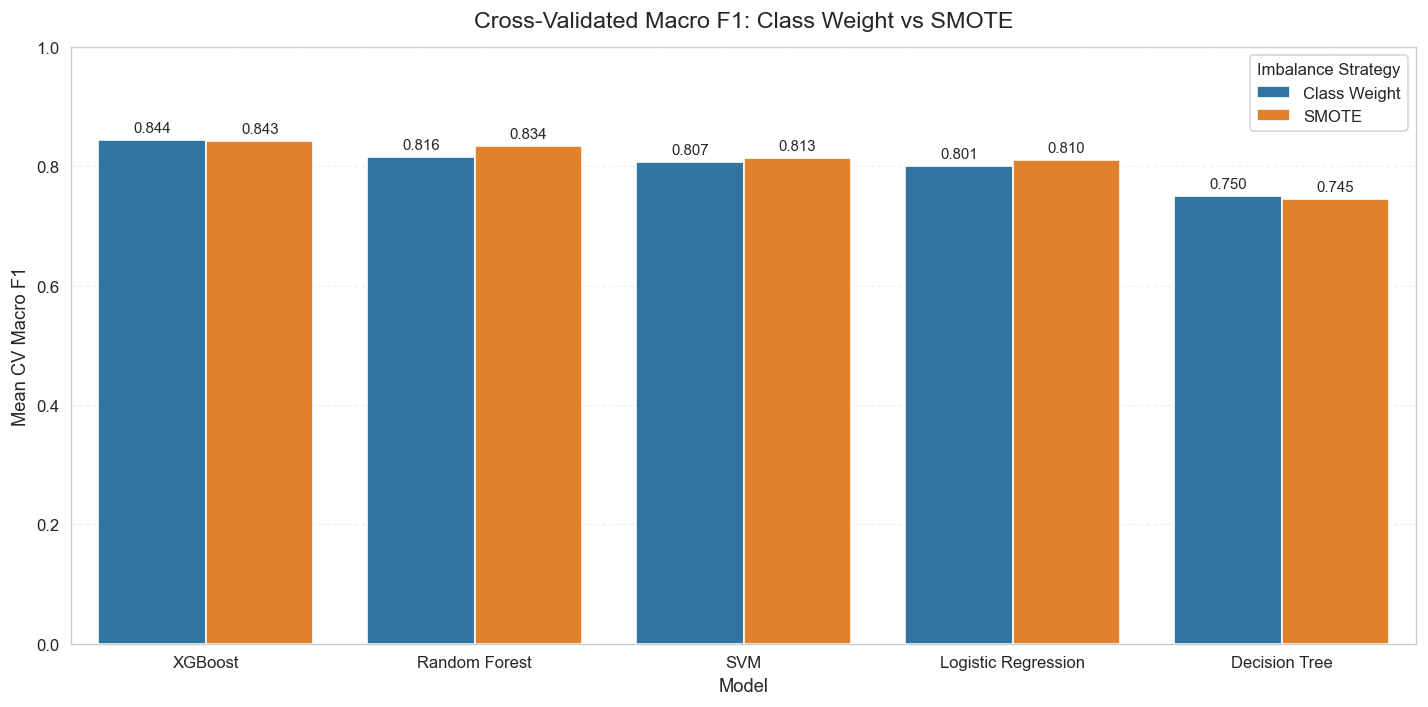

In [ ]:
# Compare Class Weight vs SMOTE

# Copy baseline class-weight results
class_weight_results = baseline_results.copy()

class_weight_results["Strategy"] = "Class Weight"

# Copy SMOTE results
smote_comparison = smote_results.copy()

smote_comparison["Strategy"] = "SMOTE"

# ---------------------------------------------------------
# Standardize model names
# Remove " + SMOTE" from SMOTE model names
# ---------------------------------------------------------
smote_comparison["Model"] = (
    smote_comparison["Model"]
    .str.replace(r"\s\***\\+**\s\*SMOTE$", "", regex=True)
)

# ---------------------------------------------------------
# Combine both strategies
# ---------------------------------------------------------
imbalance_comparison = pd.concat(
    [
        class_weight_results,
        smote_comparison
    ],
    ignore_index=True
)

# ---------------------------------------------------------
# Keep a consistent model order
# ---------------------------------------------------------
model_order = [
    "XGBoost",
    "Random Forest",
    "SVM",
    "Logistic Regression",
    "Decision Tree"
]

imbalance_comparison["Model"] = pd.Categorical(
    imbalance_comparison["Model"],
    categories=model_order,
    ordered=True
)

# Sort for clean presentation
imbalance_comparison = imbalance_comparison.sort_values(
    by=["Model", "Strategy"]
).reset_index(drop=True)

# Display comparison table
imbalance_comparison

# Visual Validation — Class Weight vs SMOTE
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=imbalance_comparison,
    x="Model",
    y="F1 Macro",
    hue="Strategy",
    order=model_order,
    hue_order=["Class Weight", "SMOTE"],
    errorbar=None
)

# ---------------------------------------------------------
# Add value labels
# ---------------------------------------------------------
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------
plt.title(
    "Cross-Validated Macro F1: Class Weight vs SMOTE",
    fontsize=14,
    pad=12
)

plt.xlabel("Model", fontsize=11)

plt.ylabel(
    "Mean CV Macro F1",
    fontsize=11
)

plt.xticks(
    rotation=0,
    fontsize=10
)

plt.yticks(
    fontsize=10
)

plt.ylim(0, 1.0)

plt.legend(
    title="Imbalance Strategy",
    loc="upper right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()


### 7.8] Hyperparameter Tuning

Tune the strongest candidate model identified during baseline
cross-validation.

XGBoost is tuned using both class weighting and SMOTE because the two
imbalance-handling strategies produced very similar baseline Macro F1
performance.

Stratified K-Fold cross-validation is retained, with Macro F1 as the
primary optimization metric.

The test set remains completely untouched.

### 7.8.1] XGBoost Hyperparameter Tuning — Standard

Tune XGBoost using the standard multiclass configuration.

XGBoost does not use class_weight or scale_pos_weight here because the
target contains three classes.

Macro F1 is used as the primary optimization metric.

### 7.8.2] XGBoost Hyperparameter Tuning — SMOTE

Tune XGBoost using SMOTE as the imbalance-handling strategy.

Preprocessing and SMOTE are contained within the same pipeline so that
both are fitted independently inside each cross-validation fold.

Macro F1 remains the primary optimization metric.

### 7.8.3] Tuned XGBoost Strategy Comparison

Compare the tuned standard XGBoost and SMOTE-based XGBoost models.

Macro F1 remains the primary selection criterion.

Balanced Accuracy, ROC-AUC, and cross-validation stability are considered
as supporting evidence.

The test set remains untouched.


In [ ]:
# XGBoost Hyperparameter Tuning — Standard

from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter search space
xgb_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

# Create the standard XGBoost pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Set up randomized hyperparameter search
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Fit the standard XGBoost model
xgb_search.fit(
    X_train,
    y_train_encoded
)

# Display the best hyperparameters
print("Best Parameters:")
print(xgb_search.best_params_)

# Display the best cross-validated F1 Macro score
print("\nBest CV F1 Macro:",
      round(xgb_search.best_score_, 4))

# XGBoost Hyperparameter Tuning — SMOTE

# Create the XGBoost pipeline with SMOTE
xgb_smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(
        random_state=42,
        k_neighbors=5
    )),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Define the SMOTE XGBoost hyperparameter search space
xgb_smote_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

# Set up randomized hyperparameter search for SMOTE
xgb_smote_search = RandomizedSearchCV(
    estimator=xgb_smote_pipeline,
    param_distributions=xgb_smote_params,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Fit the SMOTE XGBoost model
xgb_smote_search.fit(
    X_train,
    y_train_encoded
)

# Display the best SMOTE hyperparameters
print("Best Parameters:")
print(xgb_smote_search.best_params_)

# Display the best SMOTE cross-validated F1 Macro score
print("\nBest CV F1 Macro:",
      round(xgb_smote_search.best_score_, 4))

# Tuned XGBoost Strategy Comparison

# Create a comparison table for both XGBoost strategies
tuned_xgb_results = pd.DataFrame({
    "Strategy": [
        "XGBoost - Standard",
        "XGBoost - SMOTE"
    ],
    "Best CV F1 Macro": [
        xgb_search.best_score_,
        xgb_smote_search.best_score_
    ]
})

# Sort strategies by their best F1 Macro score
tuned_xgb_results = tuned_xgb_results.sort_values(
    by="Best CV F1 Macro",
    ascending=False
).reset_index(drop=True)

# Display the comparison results
tuned_xgb_results


Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}

Best CV F1 Macro: 0.8533
Best Parameters:
{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}

Best CV F1 Macro: 0.8505


,Strategy,Best CV F1 Macro
0,XGBoost - Standard,0.853297
1,XGBoost - SMOTE,0.850474


### 7.9] Random Forest Hyperparameter Tuning

Tune the Random Forest using Stratified K-Fold cross-validation and
Macro F1 as the primary optimization metric.

The preprocessing step is included inside the pipeline so that
preprocessing is fitted independently within each cross-validation fold.

The test set remains completely untouched.

### 7.10] Tuned Model Cross-Validation

Evaluate the tuned Random Forest and XGBoost models using the same
Stratified K-Fold cross-validation strategy.

Both models contain their preprocessing inside the pipeline, ensuring
consistent and leakage-safe evaluation.

Only the training dataset is used.


In [ ]:
# Random Forest Hyperparameter Tuning

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Define the hyperparameter search space
rf_params = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

# Set up randomized hyperparameter search
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Fit the Random Forest model
rf_search.fit(
    X_train,
    y_train_encoded
)

# Display the best hyperparameters
print("Best Parameters:")
print(rf_search.best_params_)

# Display the best cross-validated F1 Macro score
print("\nBest CV F1 Macro:",
      round(rf_search.best_score_, 4))

# Tuned Model Cross-Validation

# Store the tuned models
tuned_models = {
    "Random Forest Tuned": rf_search.best_estimator_,
    "XGBoost Tuned": xgb_search.best_estimator_
}

# Store cross-validation results
tuned_cv_results = {}

# Perform cross-validation for each tuned model
for name, model in tuned_models.items():

    # Calculate cross-validation metrics
    results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    # Store the results
    tuned_cv_results[name] = results

    # Display completion message
    print(f"{name} completed.")

# Create Tuned Model Comparison

# Store comparison results
tuned_comparison = []

# Calculate average metrics for each tuned model
for name, results in tuned_cv_results.items():

    tuned_comparison.append({
        "Model": name,
        "Accuracy": results["test_accuracy"].mean(),
        "Balanced Accuracy": results["test_balanced_accuracy"].mean(),
        "F1 Macro": results["test_f1_macro"].mean(),
        "F1 Weighted": results["test_f1_weighted"].mean(),
        "Precision Macro": results["test_precision_macro"].mean(),
        "Recall Macro": results["test_recall_macro"].mean(),
        "ROC-AUC": results["test_roc_auc"].mean(),
        "F1 Macro Std": results["test_f1_macro"].std()
    })

# Convert the comparison results into a DataFrame
tuned_comparison = pd.DataFrame(tuned_comparison)

# Sort models by F1 Macro score
tuned_comparison = tuned_comparison.sort_values(
    by="F1 Macro",
    ascending=False
).reset_index(drop=True)

# Display the tuned model comparison
tuned_comparison


Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20}

Best CV F1 Macro: 0.8326
Random Forest Tuned completed.
XGBoost Tuned completed.


,Model,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC,F1 Macro Std
0,XGBoost Tuned,0.920250,0.828036,0.853297,0.918064,0.883870,0.828036,0.972294,0.006754
1,Random Forest Tuned,0.909625,0.804803,0.832613,0.906874,0.866923,0.804803,0.962367,0.007945


### Phase 8] Final Model Evaluation

Evaluate the selected XGBoost model on the completely unseen test set.

The test set is used only after model selection and hyperparameter tuning
are complete.

This phase measures final predictive performance, class-level behavior,
and generalization from cross-validation to unseen data.

No further model tuning or selection is performed using test-set results.

### 8.1] Final Model Training

Train the selected tuned XGBoost pipeline on the complete training
dataset.

The preprocessing and XGBoost model remain together in the final
pipeline.

### 8.2] Test Set Prediction

Generate predictions and class probabilities on the completely unseen
test dataset using the final XGBoost pipeline.

### 8.3] Final Evaluation Metrics

Evaluate the final XGBoost model on the completely unseen test set.

Macro F1 is the primary metric because the task is multiclass
classification and class-wise performance is important.


In [ ]:
# Final Model Training
final_xgb = xgb_search.best_estimator_

final_xgb.fit(
    X_train,
    y_train_encoded
)

print("Final XGBoost model training completed.")

# Test Set Prediction
y_test_pred = final_xgb.predict(X_test)

y_test_proba = final_xgb.predict_proba(X_test)

print("Test predictions generated.")
print("Prediction Shape:", y_test_pred.shape)

# Final Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

test_metrics = {
    "Accuracy": accuracy_score(y_test_encoded, y_test_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test_encoded, y_test_pred),
    "F1 Macro": f1_score(y_test_encoded, y_test_pred, average="macro"),
    "F1 Weighted": f1_score(y_test_encoded, y_test_pred, average="weighted"),
    "Precision Macro": precision_score(
        y_test_encoded, y_test_pred, average="macro"
    ),
    "Recall Macro": recall_score(
        y_test_encoded, y_test_pred, average="macro"
    ),
    "ROC-AUC": roc_auc_score(
        y_test_encoded,
        y_test_proba,
        multi_class="ovr"
    )
}

for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")


Final XGBoost model training completed.
Test predictions generated.
Prediction Shape: (2000,)
Accuracy: 0.9350
Balanced Accuracy: 0.8743
F1 Macro: 0.8850
F1 Weighted: 0.9342
Precision Macro: 0.8965
Recall Macro: 0.8743
ROC-AUC: 0.9829


### 8.4] Confusion Matrix

Analyze class-level prediction performance of the final model.

The confusion matrix identifies which target classes are correctly
classified and where misclassification occurs.

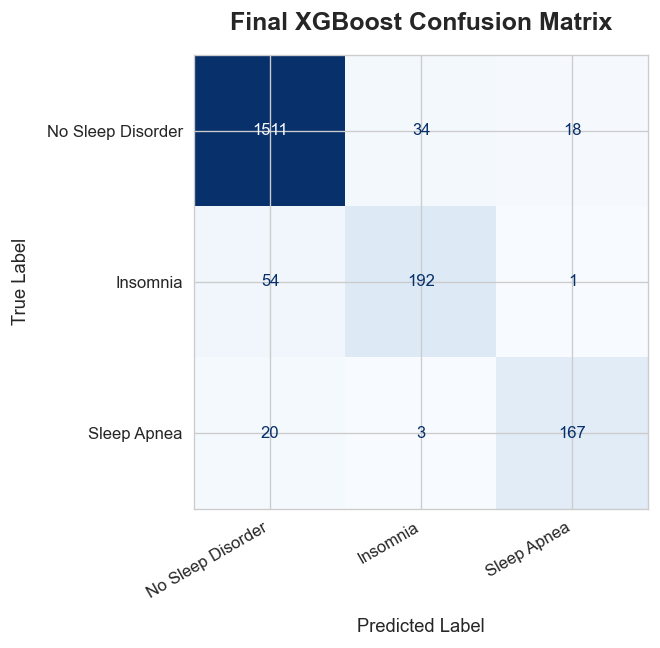

In [ ]:
# Final XGBoost Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

# Create the confusion matrix figure
fig, ax = plt.subplots(figsize=(7, 5.5))

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_test_pred,
    display_labels=[
        "No Sleep Disorder",
        "Insomnia",
        "Sleep Apnea"
    ],
    cmap="Blues",
    colorbar=False,
    values_format="d",
    ax=ax
)

# Add the confusion matrix title
ax.set_title(
    "Final XGBoost Confusion Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Add the x-axis label
ax.set_xlabel(
    "Predicted Label",
    fontsize=11,
    labelpad=10
)

# Add the y-axis label
ax.set_ylabel(
    "True Label",
    fontsize=11,
    labelpad=10
)

# Format the axis tick labels
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the confusion matrix
plt.show()

### Confusion Matrix — Key Insights

- **Strong overall class separation** across all three sleep-disorder categories.
- **No Sleep Disorder:** Highest recognition with ~96.7% recall.
- **Sleep Apnea:** Strong recognition with ~87.9% recall.
- **Insomnia:** Moderate recognition with ~77.7% recall.
- **Primary error:** Insomnia is most often misclassified as No Sleep Disorder.
- **Minimal confusion:** Very few Insomnia ↔ Sleep Apnea misclassifications.
- **Overall insight:** The model generalizes well, with **Insomnia vs. No Sleep Disorder** remaining the main area for improvement.

### 8.5] Multiclass ROC-AUC Curve

Visualize the One-vs-Rest ROC curves for all three target classes.

ROC-AUC evaluates how effectively the final model separates each class
from the remaining classes across different classification thresholds.


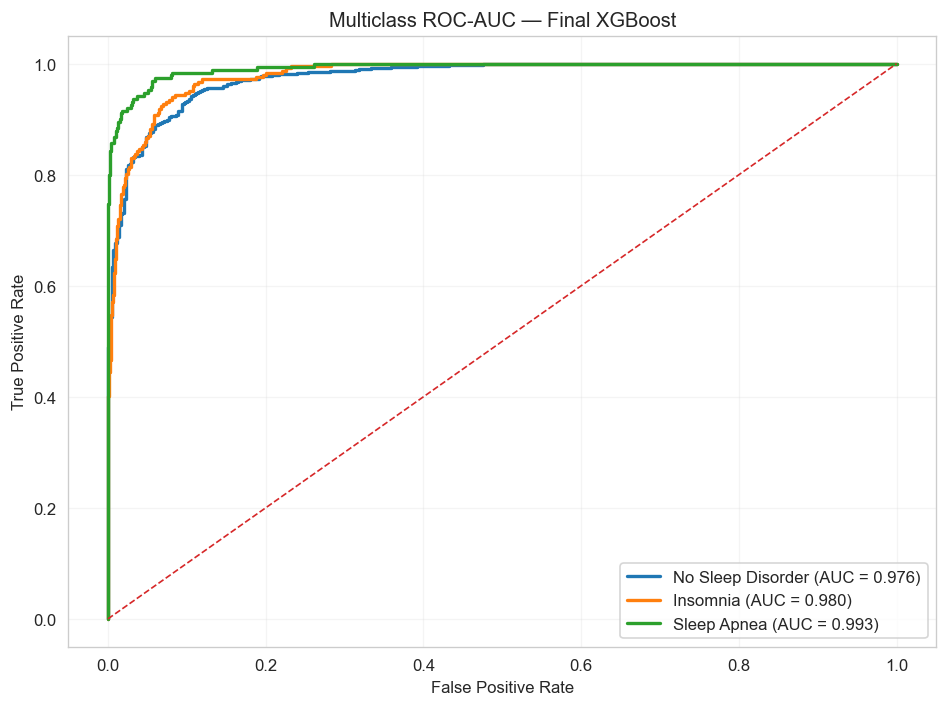

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert multiclass target into One-vs-Rest format
y_test_binary = label_binarize(
    y_test_encoded,
    classes=[0, 1, 2]
)

class_names = [
    "No Sleep Disorder",
    "Insomnia",
    "Sleep Apnea"
]

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):

    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        y_test_proba[:, i]
    )

    # Calculate the AUC score
    class_auc = auc(fpr, tpr)

    # Plot the ROC curve for the class
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

# Add axis labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Add the plot title
plt.title("Multiclass ROC-AUC — Final XGBoost")

# Display the legend
plt.legend()

# Add grid lines
plt.grid(alpha=0.2)

# Adjust the layout
plt.tight_layout()

# Display the ROC-AUC curve
plt.show()



### Key Insight

> **The ROC-AUC curves demonstrate strong class-wise discrimination, with AUC above 0.97 for all three classes. Sleep Apnea shows the strongest discrimination (AUC = 0.993), followed by Insomnia (AUC = 0.980) and No Sleep Disorder (AUC = 0.976), indicating that the final XGBoost model effectively separates all three classes across classification thresholds.**

### 8.6] Precision–Recall Curve and PR-AUC

For the imbalanced multiclass target, Precision–Recall analysis is used alongside ROC-AUC to assess class-specific performance.  
The curves show the precision–recall trade-off across thresholds, while PR-AUC summarizes this performance.  
One-vs-Rest PR curves are plotted for each sleep-disorder class using the final XGBoost model.  
Particular attention is given to the more difficult and less-separated classes.

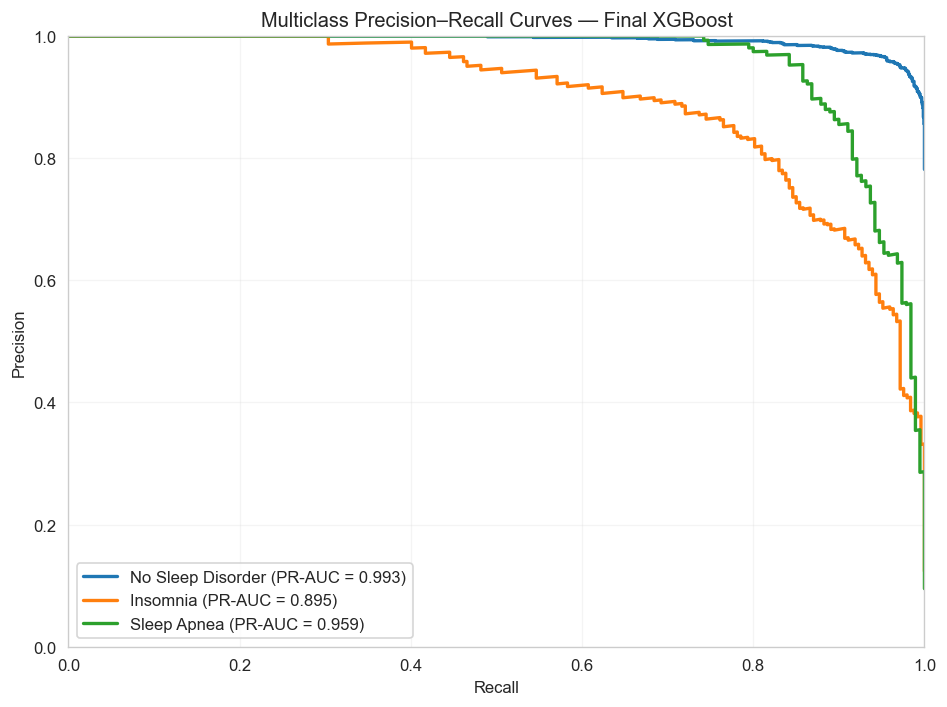

Class-wise PR-AUC:
No Sleep Disorder: 0.9929
Insomnia: 0.8951
Sleep Apnea: 0.9585


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Convert multiclass target into One-vs-Rest format
y_test_binary = label_binarize(
    y_test_encoded,
    classes=[0, 1, 2]
)

class_names = [
    "No Sleep Disorder",
    "Insomnia",
    "Sleep Apnea"
]

plt.figure(figsize=(8, 6))

pr_auc_scores = {}

for i, class_name in enumerate(class_names):

    precision, recall, _ = precision_recall_curve(
        y_test_binary[:, i],
        y_test_proba[:, i]
    )

    pr_auc = average_precision_score(
        y_test_binary[:, i],
        y_test_proba[:, i]
    )

    pr_auc_scores[class_name] = pr_auc

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{class_name} (PR-AUC = {pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Multiclass Precision–Recall Curves — Final XGBoost"
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# Display class-wise PR-AUC
print("Class-wise PR-AUC:")

for class_name, score in pr_auc_scores.items():
    print(f"{class_name}: {score:.4f}")

> **Key Insight:** The PR curves demonstrate strong class-wise performance, with PR-AUC above **0.95** for No Sleep Disorder and Sleep Apnea. **Insomnia** is comparatively more difficult to identify, consistent with the class overlap observed in the confusion matrix.



### 8.7] SHAP Model Explainability

Use SHAP to identify the features that have the greatest influence on
the final XGBoost predictions.

The analysis is performed on the transformed feature space used by
XGBoost, while the original feature names are retained for interpretation.

### 8.7.1] Prepare Data for SHAP

Prepare the test data using the fitted preprocessing pipeline and extract
the transformed feature names required for SHAP-based model explainability.


In [ ]:
# Prepare Data for SHAP

# Extract fitted preprocessing and XGBoost model
fitted_preprocessor = final_xgb.named_steps["preprocessor"]
xgb_model = final_xgb.named_steps["model"]

# Transform test data using the fitted preprocessor
X_test_transformed = fitted_preprocessor.transform(X_test)

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Convert to DataFrame for readability
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

print("SHAP Input Shape:", X_test_shap.shape)

SHAP Input Shape: (2000, 30)


### 8.7.2] Generate SHAP Values

Calculate SHAP values for the final XGBoost model to quantify the
contribution of each feature to the model's predictions.

In [ ]:
# Generate SHAP Values
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_shap)

print("SHAP analysis completed.")


SHAP analysis completed.


### 8.7.3] Global SHAP Feature Importance

Identify the features with the greatest overall influence on the final
XGBoost model across the test observations.

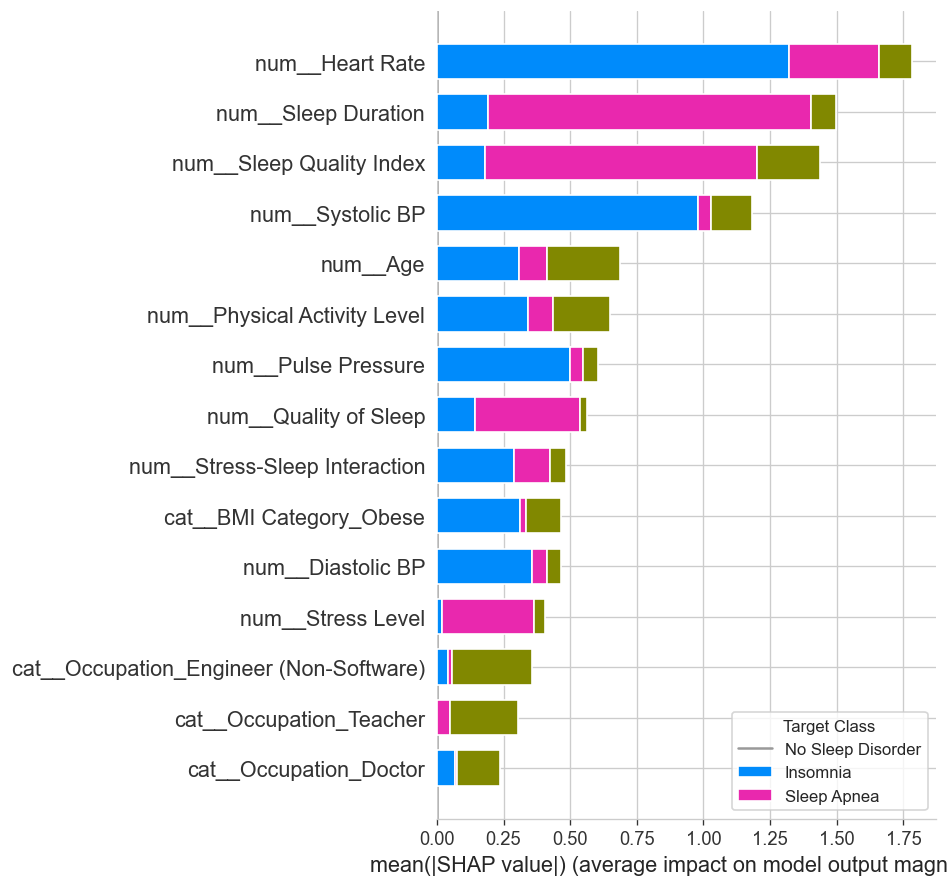

In [ ]:
# Global SHAP Feature Importance
class_names = [
    "No Sleep Disorder",
    "Insomnia",
    "Sleep Apnea"
]

shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.legend(
    labels=class_names,
    title="Target Class"
)

plt.tight_layout()
plt.show()

### SHAP Global Feature Importance — Key Insights

- **Heart Rate** is the most influential feature across the three target classes.
- **Sleep Duration** and **Sleep Quality Index** are the next most influential features.
- **Systolic Blood Pressure** and **Age** also have substantial influence on model predictions.
- **Physical Activity Level** and **Pulse Pressure** provide additional predictive contribution.
- **Quality of Sleep** and **Stress–Sleep Interaction** show meaningful class-specific influence.
- **BMI Category (Obese)** contributes noticeably, but less than the major physiological and sleep-related features.
- **Occupation-related features** have comparatively lower overall influence.
- **Overall insight:** The model's predictions are driven primarily by **sleep characteristics and physiological health indicators**, rather than demographic/occupational features.
- **Explainability insight:** SHAP confirms that the final XGBoost model is relying substantially on **domain-relevant sleep and health features** rather than a small number of categorical variables.

### 8.7.4] SHAP Summary Plot

Visualize both the magnitude and direction of feature contributions
to the model's predictions.


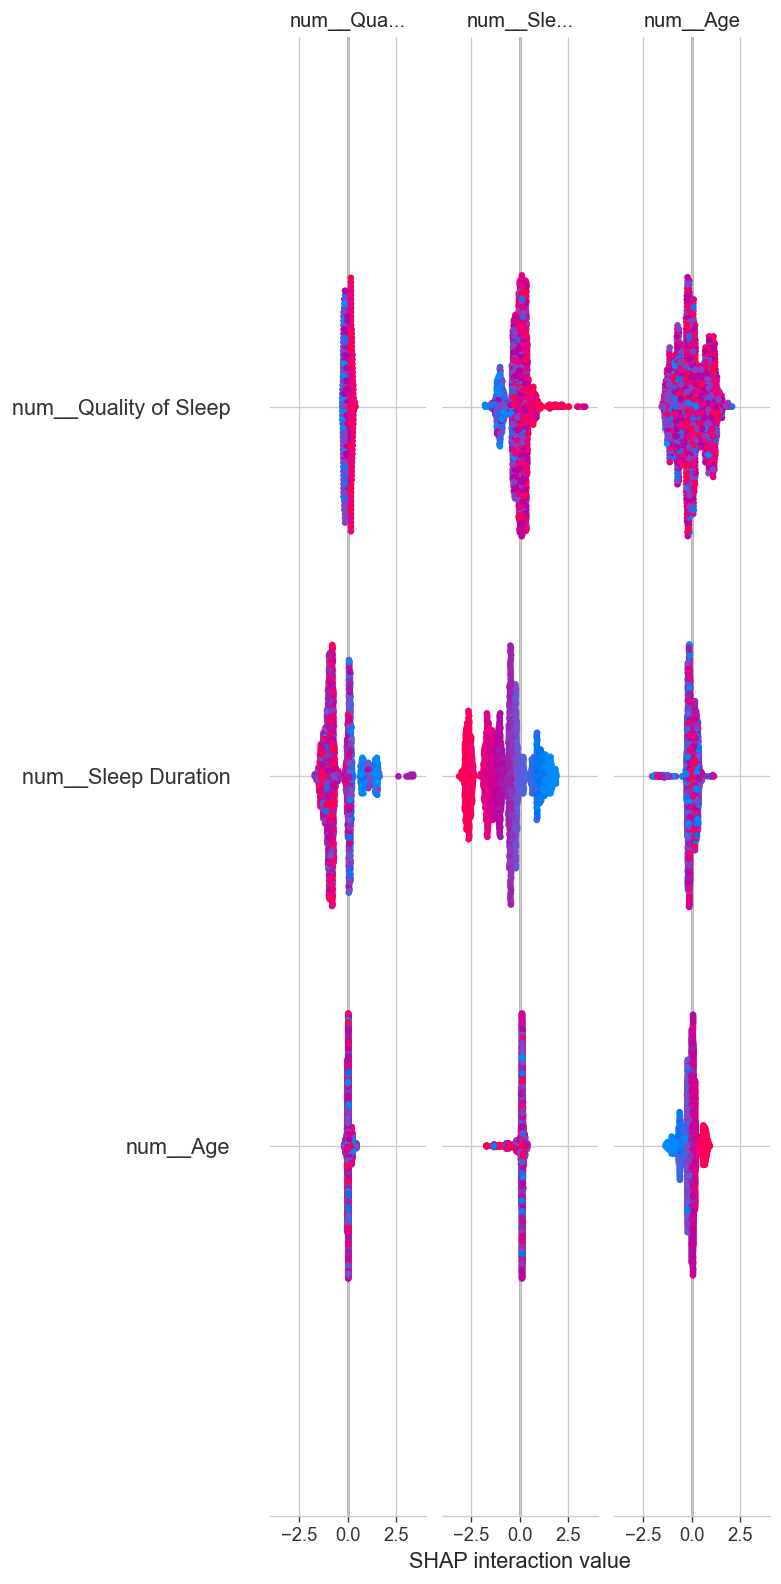

In [ ]:
# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    max_display=15
)

### SHAP Interaction Analysis — Key Insights

- **Sleep Duration** shows the strongest interaction effects among the features displayed.
- **Quality of Sleep** also shows meaningful interactions, particularly across different target classes.
- **Age** contributes noticeable class-specific interaction effects, but with comparatively smaller magnitude.
- **Overall insight:** The model captures important **interactions between sleep-related features and demographic factors**, rather than relying only on individual feature effects.

### 8.8] Class-wise Precision–Recall–F1 Analysis

Evaluate the final XGBoost model's precision, recall, and F1-score
separately for each sleep-disorder class.

This provides a class-level view of model performance and highlights
where the model performs strongly or where classification remains
challenging.


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Human-readable class names
class_names = [
    "No Sleep Disorder",
    "Insomnia",
    "Sleep Apnea"
]

# Calculate class-wise metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_encoded,
    y_test_pred,
    labels=[0, 1, 2],
    zero_division=0
)

# Create results table
class_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

print(class_metrics)

               Class  Precision    Recall  F1 Score
0  No Sleep Disorder   0.953312  0.966731  0.959975
1           Insomnia   0.838428  0.777328  0.806723
2        Sleep Apnea   0.897849  0.878947  0.888298


### 8.8.1] Class-wise Performance Visualization

Compare precision, recall, and F1-score across all three target classes.

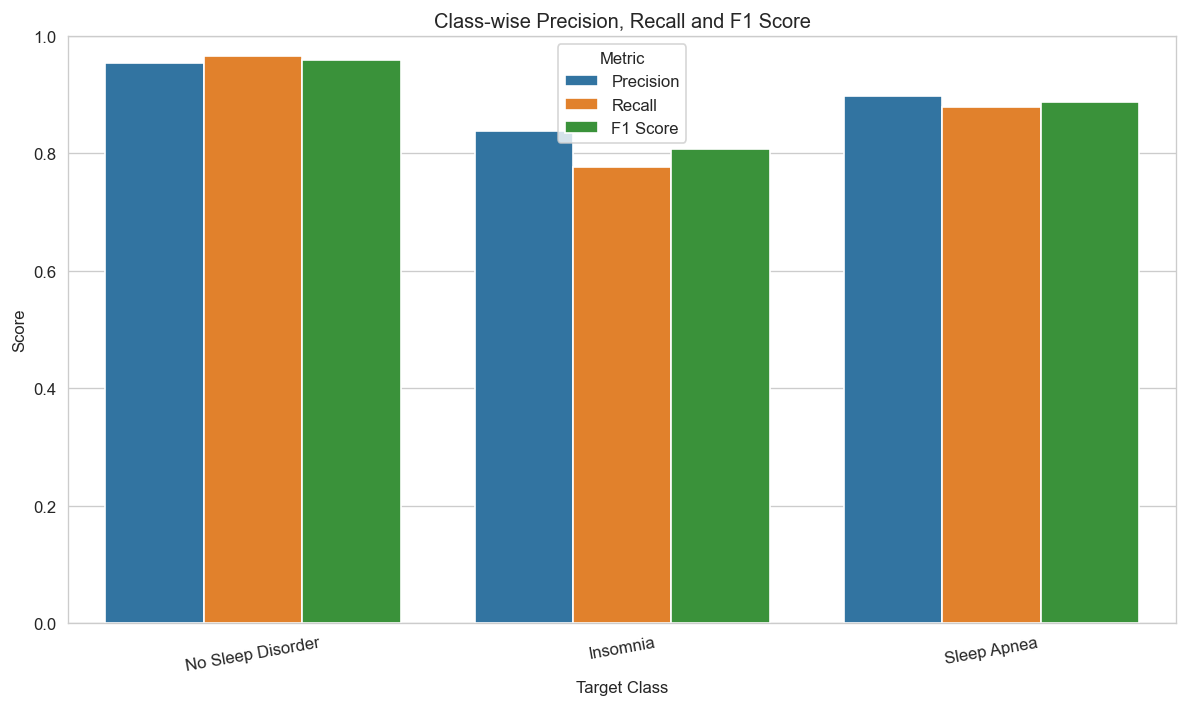

In [ ]:
metrics_long = class_metrics.melt(
    id_vars="Class",
    value_vars=["Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=metrics_long,
    x="Class",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1)
plt.xlabel("Target Class")
plt.ylabel("Score")
plt.title("Class-wise Precision, Recall and F1 Score")
plt.xticks(rotation=10)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Phase 9] Key Findings

1. **Heart Rate, Sleep Duration, and Sleep Quality Index** are the strongest predictors of sleep-disorder status, per SHAP global feature importance.
2. **Sleep Apnea** is driven primarily by elevated blood pressure and heart rate; **Insomnia** by lower sleep quality/duration and higher stress — consistent across both the EDA relationship analysis and the SHAP feature attributions.
3. **Class weighting and SMOTE performed comparably** in cross-validation; class weighting was marginally better and simpler to deploy (no synthetic data generation needed at inference time).
4. **XGBoost outperformed all other candidates** (Logistic Regression, Decision Tree, Random Forest, SVM) under every configuration tested — both imbalance-handling strategies, and both before and after tuning.
5. **Insomnia is the hardest class to separate from a healthy sleep profile** — reflected in its lower precision/recall/F1 in the class-wise evaluation, and the clearest target for future feature or data improvements.


### Conclusion

This project developed an **explainable multiclass machine learning solution** for classifying **No Sleep Disorder, Insomnia, and Sleep Apnea** using demographic, lifestyle, and physiological features.

After comparing multiple classifiers, class-weighting and SMOTE strategies, and tuning the strongest candidates, **XGBoost** achieved the best final test performance with **93.50% accuracy, 88.50% Macro F1, 87.43% balanced accuracy, and 98.29% ROC-AUC**. SHAP analysis provided insight into the features influencing model predictions, while class-level evaluation showed that **Insomnia was more difficult to distinguish from No Sleep Disorder** than the other classes.
The final model is prepared for deployment through a **Flask-based web application**.



### Phase 10] Business Impact & Recommendations

- Positioned as a screening/triage aid, not a diagnostic tool — flags 
  at-risk individuals using data already routinely collected, without 
  requiring a clinical sleep study.
- Enables early detection at near-zero marginal cost per user, making 
  it viable as an always-on feature in health apps or wellness platforms.
- SHAP-based explainability supports clinical and end-user trust, 
  which is necessary for real-world adoption of any health-related 
  prediction.
- Deployed as a Flask web application, keeping the path from model to 
  usable product short.
- **Recommendation:** prioritize improving Insomnia-class separation 
  (via richer features or more balanced data) before wider deployment, 
  since it is currently the weakest-performing class.